In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from tqdm import tqdm
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import statsmodels.api as sm
from sklearn.metrics import mean_poisson_deviance, accuracy_score

from sklearn.model_selection import KFold
from pyglmnet import GLM

import torch
import torch.nn as nn

from sklearn.linear_model import LogisticRegression

from statsmodels.discrete.discrete_model import PerfectSeparationWarning
from statsmodels.tools.sm_exceptions import ConvergenceWarning

!!!! Assumes that the correct data has been downloaded to ./Data  !!!!

Also, when using 
```
"numpy>=2.3.5",
"pyglmnet>=1.1"
```
the pyglmnet package is deprecated... so we need to fix on line 230 of the pyglmnet.py file of the package the np.float(...) to np.float64(...) -_-

# Data Pre-processing

## 1. Merge the multiple data files

In [137]:
CHANGE_PATH = "data/change-metrics.csv"
CK_PATH     = "data/single-version-ck-oo.csv"
OUT_PATH    = "data/equinox_merged_32feat_plus_bugs.csv"

BUG_META_COLS = {"bugs", "nonTrivialBugs", "majorBugs", "criticalBugs", "highPriorityBugs"}

FOLDER_EXPORTS = "./imgs_partB"

In [138]:
def read_semicolon_csv(path: str) -> pd.DataFrame:

    df = pd.read_csv(path, sep=";")
    df.columns = [c.strip() for c in df.columns]
    df = df.drop(columns='')
    if "classname" not in df.columns:
        raise ValueError(f"'classname' column not found in {path}. Columns: {df.columns.tolist()}")
    df["classname"] = df["classname"].astype(str).str.strip()
    return df

In [139]:
df_change = read_semicolon_csv(CHANGE_PATH)
df_ck     = read_semicolon_csv(CK_PATH)

change_feat_cols = [c for c in df_change.columns if c not in ({"classname"} | BUG_META_COLS)]
ck_feat_cols     = [c for c in df_ck.columns     if c not in ({"classname"} | BUG_META_COLS)]

merged = df_change[["classname", "bugs"] + change_feat_cols].merge(
    df_ck[["classname"] + ck_feat_cols],  
    on="classname",
    how="inner",
    validate="one_to_one"
)

feature_cols = change_feat_cols + ck_feat_cols
for c in feature_cols + ["bugs"]:
    merged[c] = pd.to_numeric(merged[c], errors="coerce")

n_rows = merged.shape[0]
n_features = len(feature_cols)

if n_rows != 324:
    raise ValueError(f"Expected 324 rows after merge, got {n_rows}. Check join key / missing classes.")

if n_features != 32:
    raise ValueError(
        f"Expected 32 features (15 change + 17 CK/OO), got {n_features}.\n"
        f"Change features: {len(change_feat_cols)}; CK/OO features: {len(ck_feat_cols)}.\n"
        f"Change feat cols: {change_feat_cols}\n"
        f"CK/OO feat cols: {ck_feat_cols}"
    )

final_cols = feature_cols + ["bugs"]
final = merged[final_cols].copy()

final.to_csv(OUT_PATH, index=False)
print(f"Saved merged dataset to: {OUT_PATH}")
print("Shape:", final.shape)

Saved merged dataset to: data/equinox_merged_32feat_plus_bugs.csv
Shape: (324, 33)


## 2. Pre-Process the Data
In this case, we normalize the features, such that they have a mean of 0 and a standard deviation of 1.
The response variable bugs is left as is, as we will be fitting a poisson regression model.

Lastly, we normalize the data w.r.t. the mean and std of the train set, otherwise some information spillage would take place.

In [204]:
df = pd.read_csv(OUT_PATH)

bins = [-1, 0, 2, 5, np.inf]
labels = ["0", "1-2", "3-5", "6+"]

df["bug_bin"] = pd.cut(
    df["bugs"],
    bins=bins,
    labels=labels
)

train_df_raw, test_df_raw = train_test_split(
    df,
    test_size=0.33,
    stratify=df["bug_bin"],  
    random_state=42
)

train_df_raw = train_df_raw.drop(columns=["bug_bin"])
test_df_raw  = test_df_raw.drop(columns=["bug_bin"])

# normalize the features to be distributed as N(0, 1)
features = [c for c in train_df_raw.columns if c != "bugs" and c != "bug_bin"]
scaler = StandardScaler()

# not the best practice, but our dataset is quite small so it's okay I believe
train_df = train_df_raw.copy()
test_df  = test_df_raw.copy()

train_df[features] = scaler.fit_transform(train_df_raw[features].values)
test_df[features] = scaler.transform(test_df_raw[features].values)

# 输出路径
TRAIN_PATH = "Data/train_data_normalized.csv"
TEST_PATH  = "Data/test_data_normalized.csv"

train_df.to_csv(TRAIN_PATH, index=False)
test_df.to_csv(TEST_PATH, index=False)

print("Train and test datasets saved.")
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train and test datasets saved.
Train shape: (217, 33)
Test shape : (107, 33)


# Data Exploration

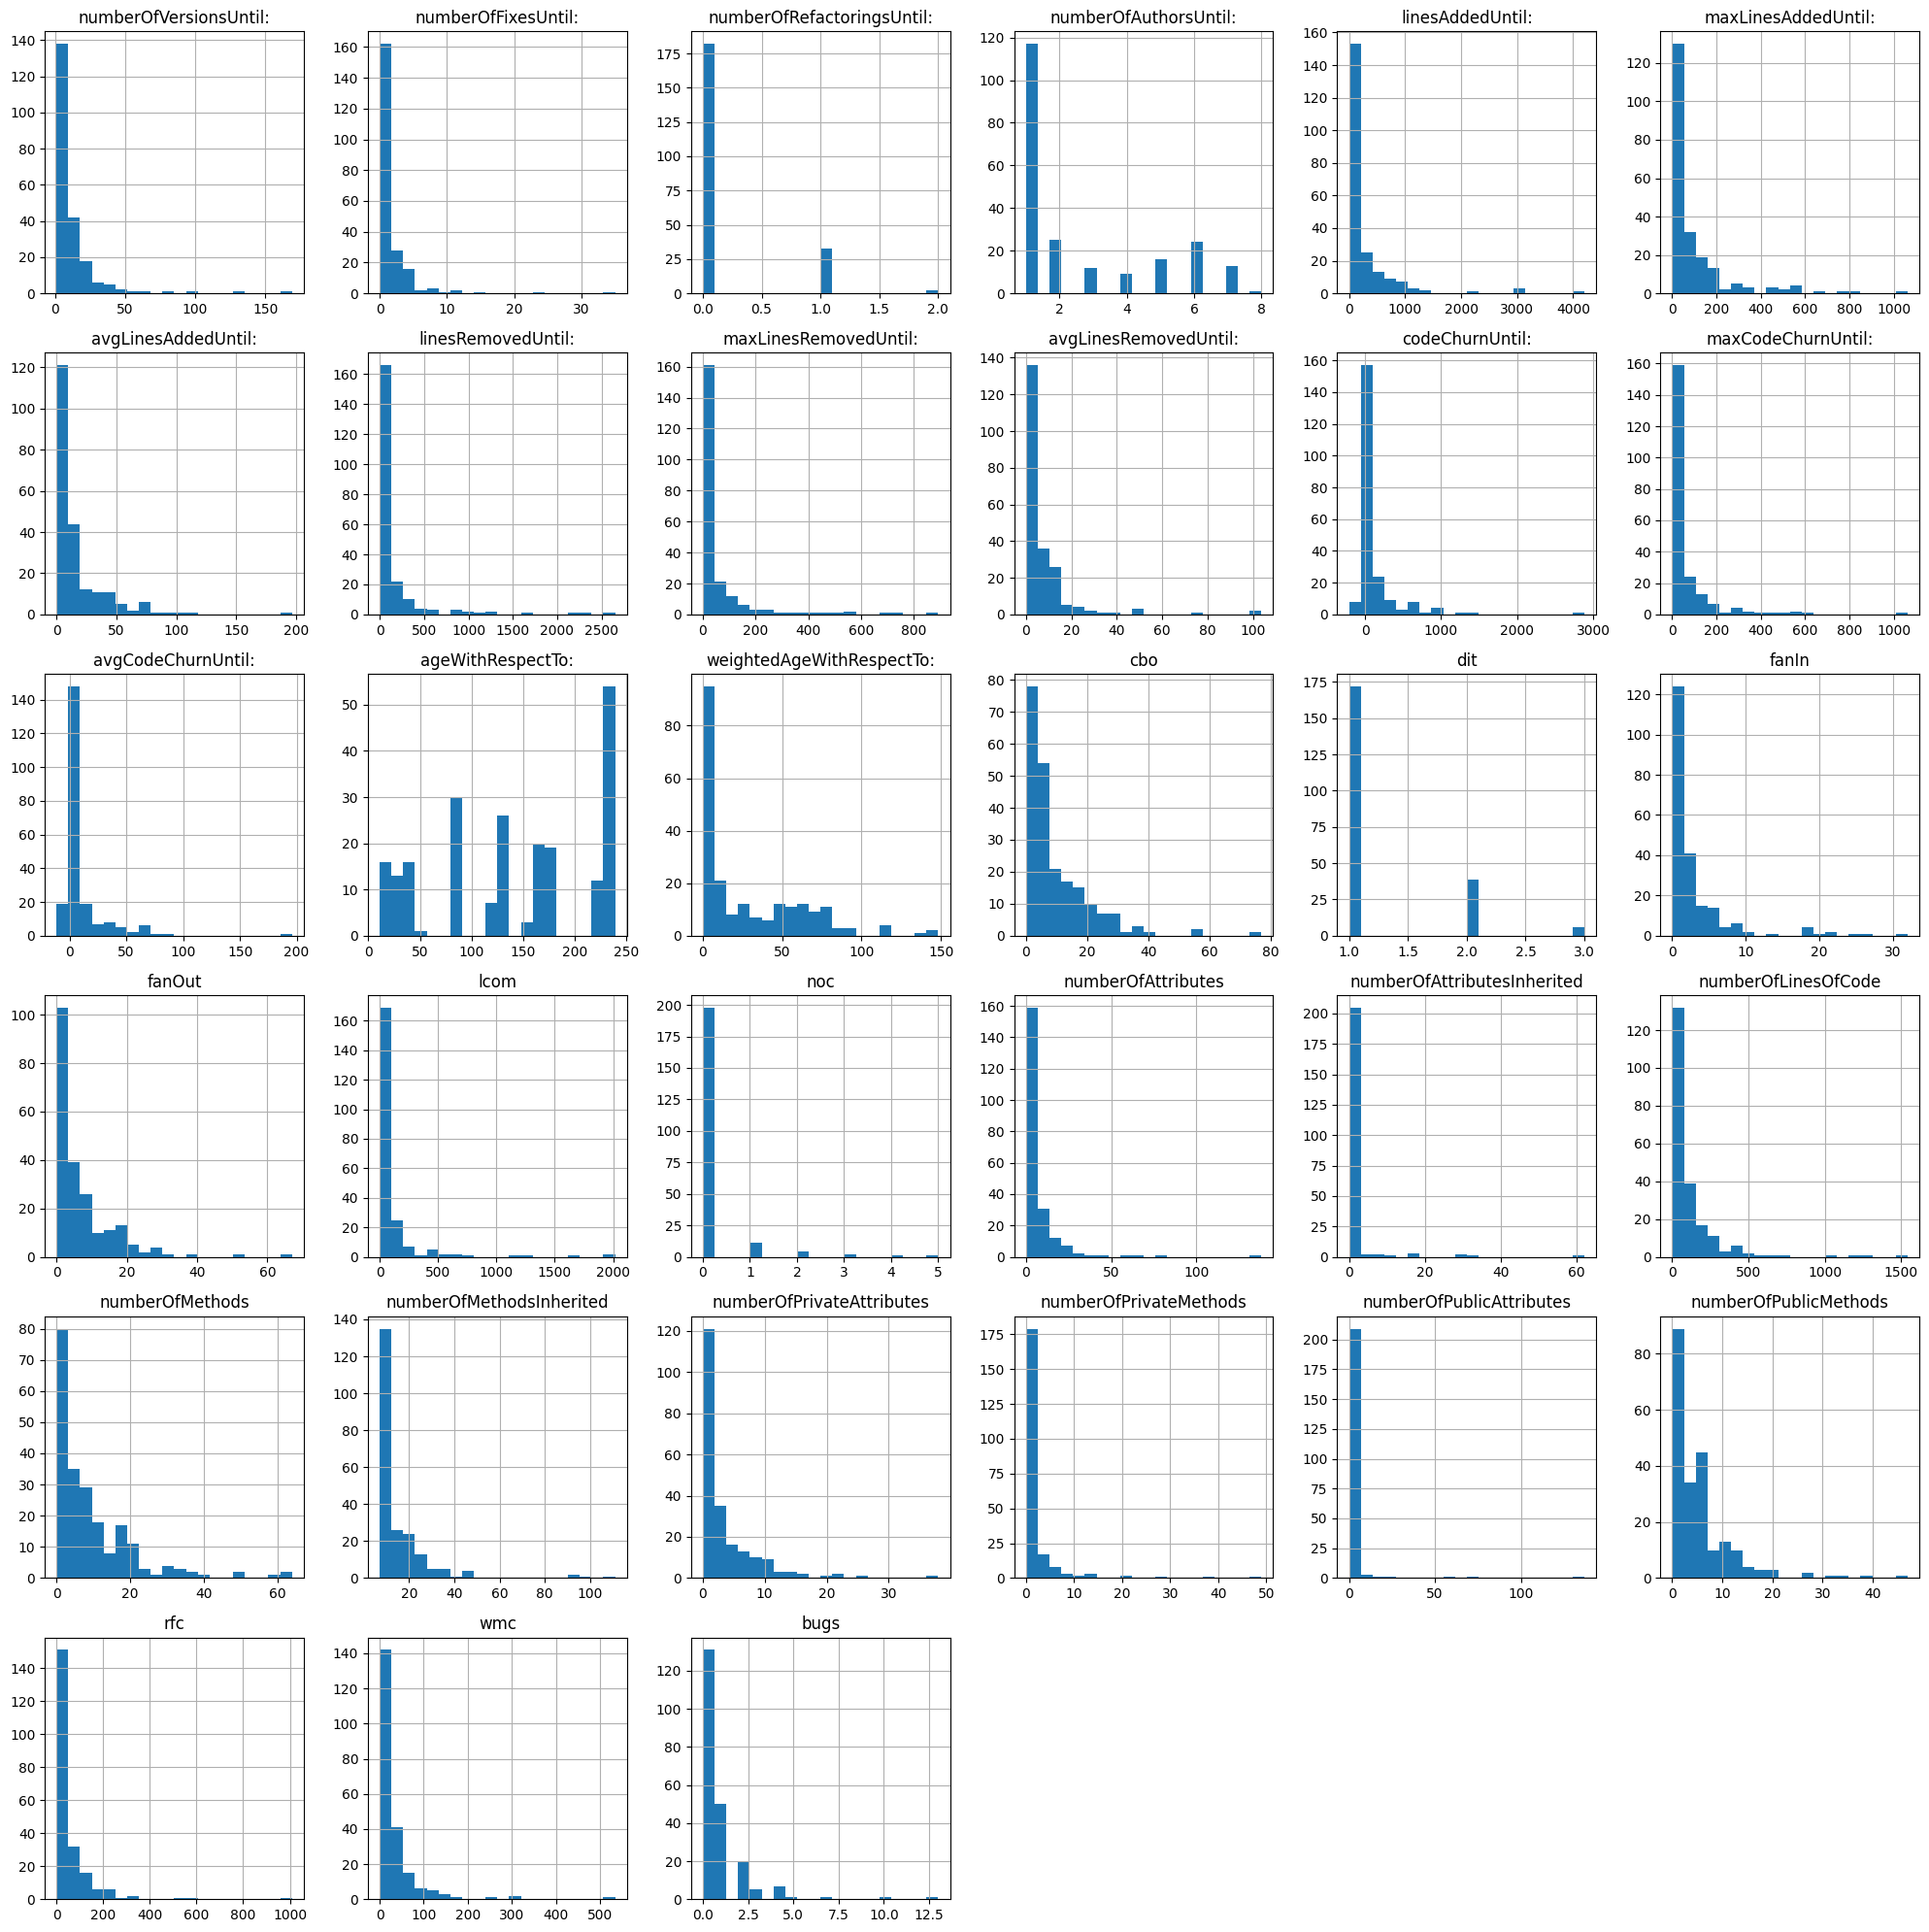

In [205]:
train_df_raw.hist(figsize=(20, 20), bins=20)
plt.gcf().tight_layout()
plt.gcf().savefig(f"{FOLDER_EXPORTS}/raw_feature_histograms.png")
# plt.close()

We clearly see that the features are **heavily** skewed and most of the values are close to zero with heavy tails to the right (e.g. numberOfLinesOfCode has values up to 1500, even though most of the values are close to zero).

To counteract this, as we believe that the skewed distribution might hinder the training of an effective model, we first transform the features to the log-space, and then normalize them to have a mean of zero and a standard deviation of 1.

In [247]:
# plot the histogram of all of the features for the training set
train_df_clone = train_df_raw.copy()
test_df_clone = test_df_raw.copy()

# ! this allows for data leakage. However, using any arbitrary value (like 10 000) would also allow the log transform to not return -inf.
min_val = np.minimum(train_df_clone[features].min().values, test_df_clone[features].min().values)
min_val = np.abs(min_val)

# # 1. log transform
train_df_clone[features] = np.log(train_df_clone[features] + min_val + 1)
test_df_clone[features]  = np.log(test_df_clone[features] + min_val + 1)

# # 2. normalize
scaler_log_transformed = StandardScaler()
train_df_clone[features] = scaler_log_transformed.fit_transform(train_df_clone[features].values)
test_df_clone[features]  = scaler_log_transformed.transform(test_df_clone[features].values)

# min_val

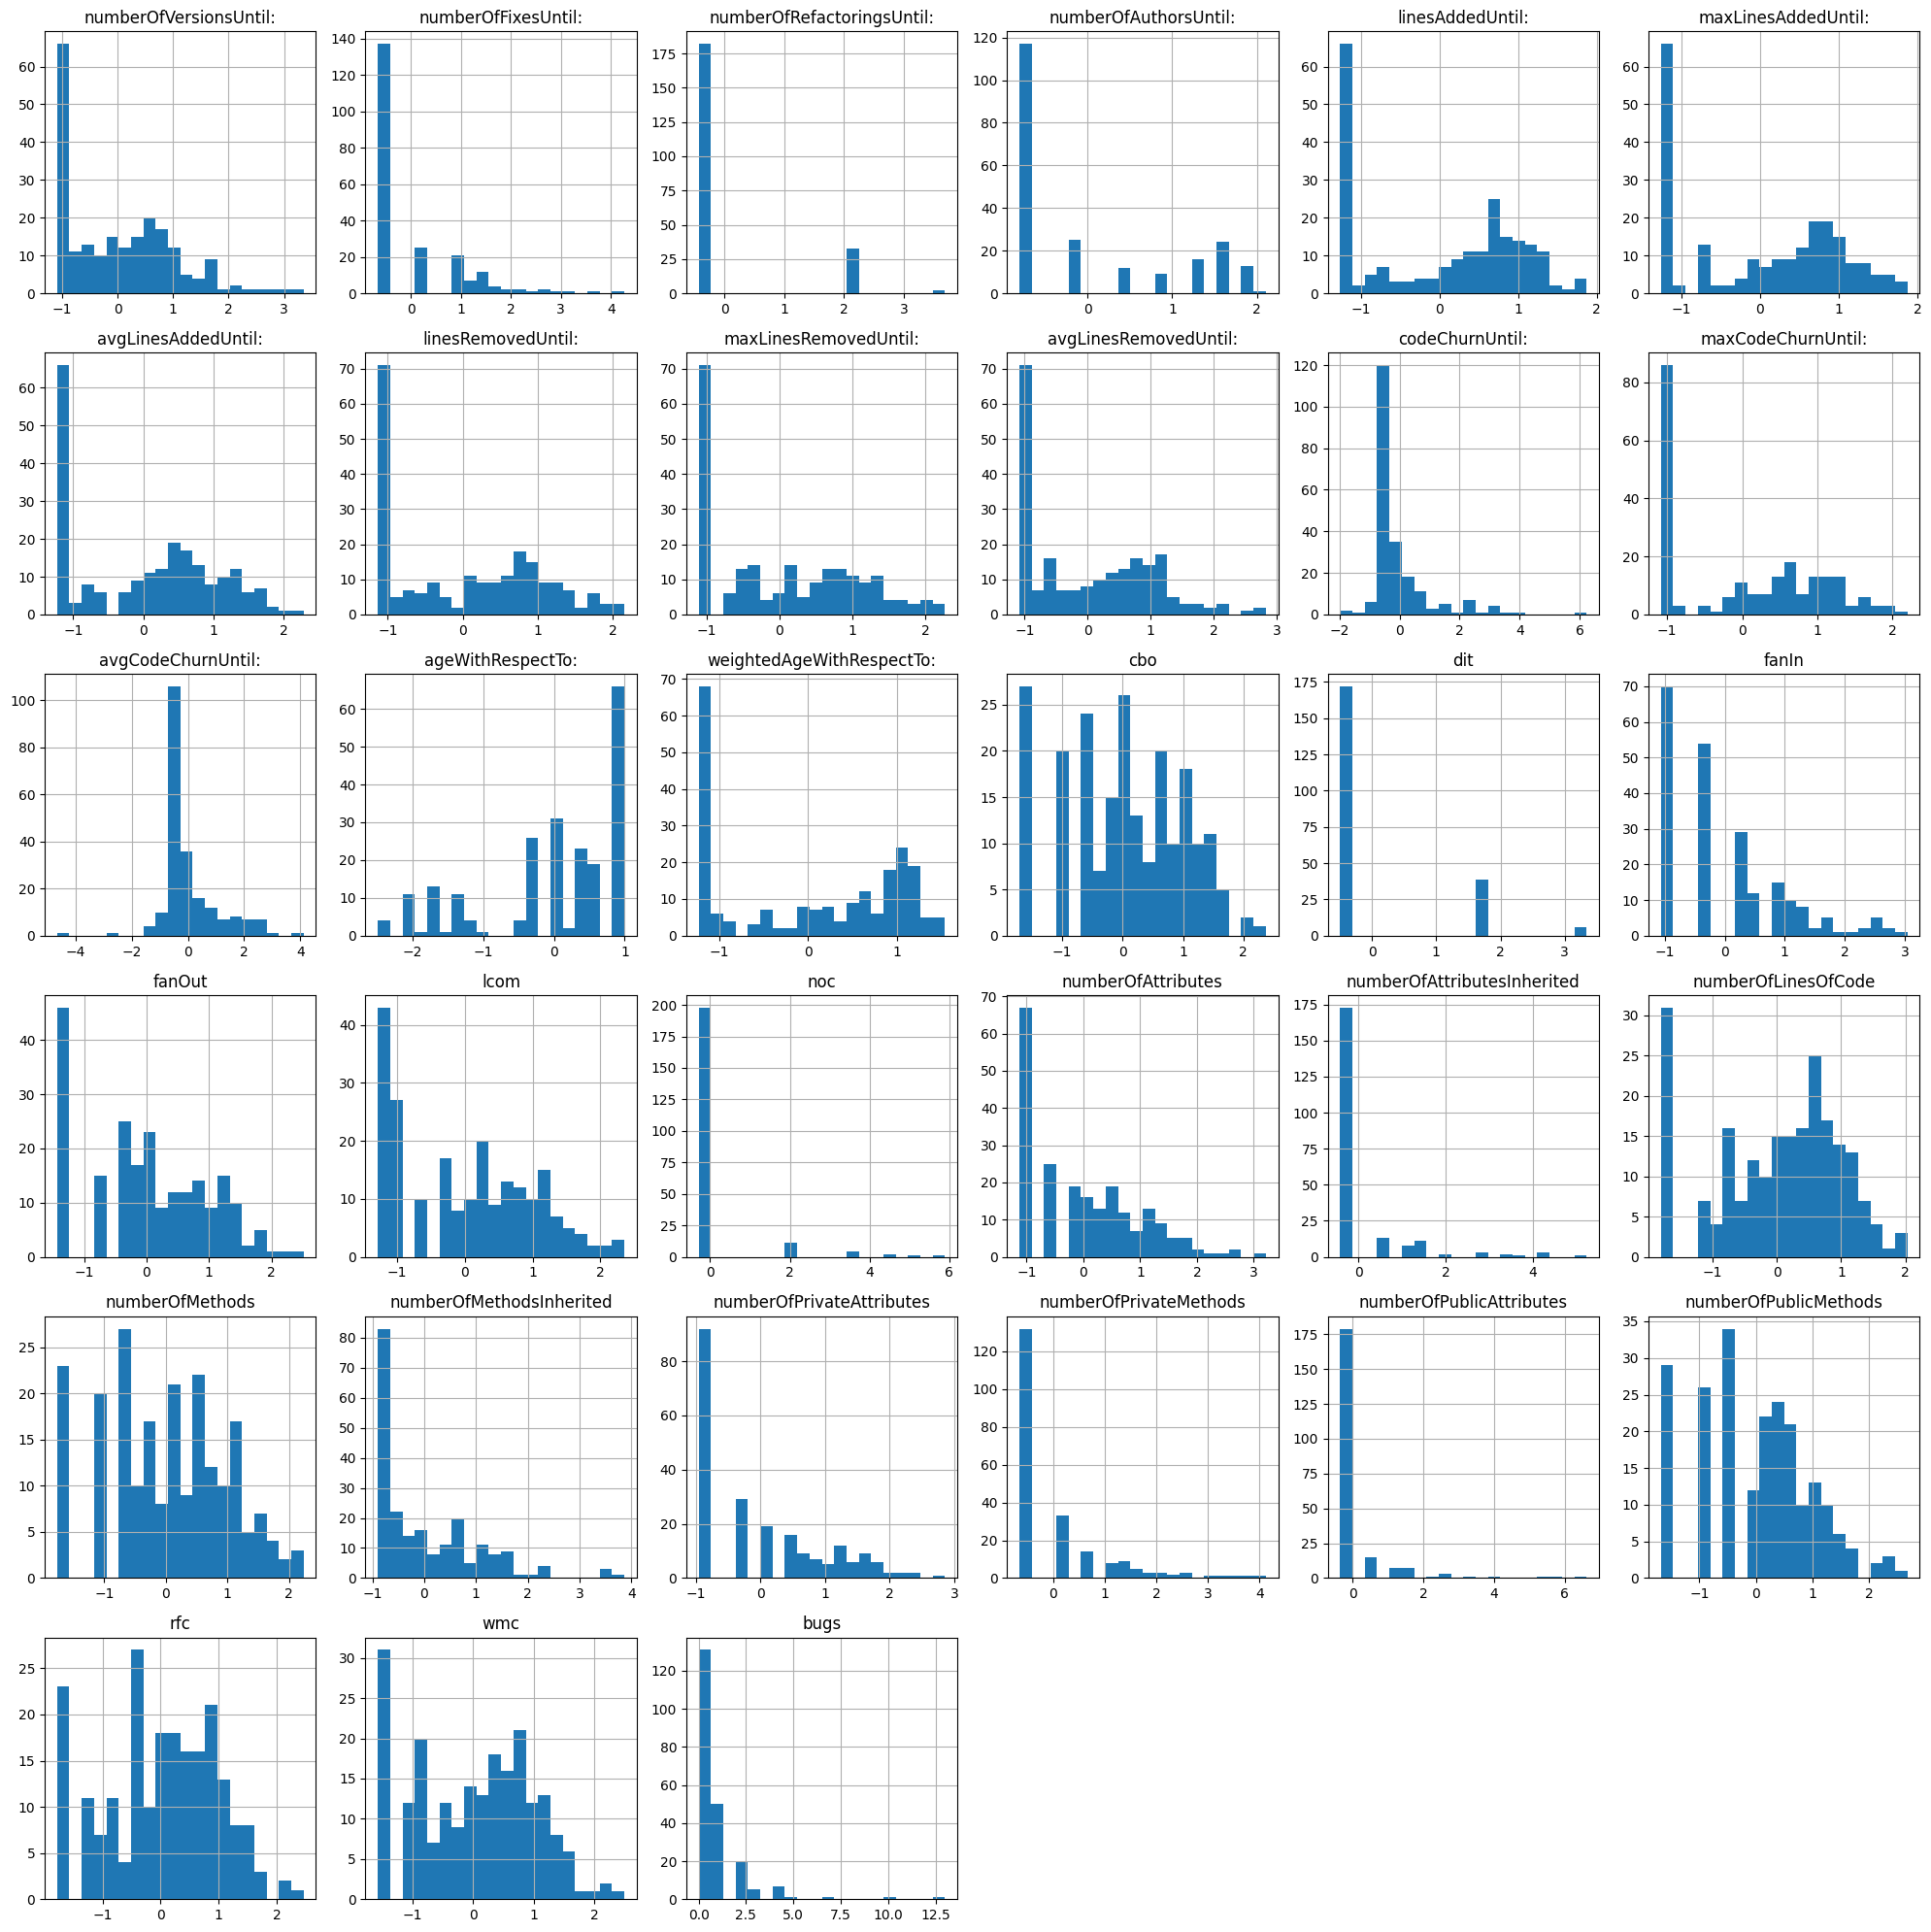

In [248]:
train_df_clone.hist(figsize=(20, 20), bins=20)
plt.gcf().tight_layout()
plt.gcf().savefig(f"{FOLDER_EXPORTS}/raw_feature_histograms_log_and_normalized.png")


In [249]:
# set the log-transformed and normalized features as the default features
train_df = train_df_clone.copy()
test_df  = test_df_clone.copy()

# create the just normalized features dataframe
train_df_normalized = train_df_raw.copy()
test_df_normalized = test_df_raw.copy()
scaler_normalized = StandardScaler()
train_df_normalized[features] = scaler_normalized.fit_transform(train_df_normalized[features].values)
test_df_normalized[features]  = scaler_normalized.transform(test_df_normalized[features].values)


# Stepwise Poisson Regression

In [360]:
X_cols = [c for c in train_df.columns if c != "bugs"]
print(len(X_cols), 'features found')

# the log-transformed and normalized features
use_log_transformed = True

if use_log_transformed:
    X_train = train_df[X_cols]
    y_train = train_df["bugs"]

    X_test  = test_df[X_cols]
    y_test  = test_df["bugs"]
else:
    X_train = train_df_normalized[X_cols]
    y_train = train_df_normalized["bugs"]

    X_test  = test_df_normalized[X_cols]
    y_test  = test_df_normalized["bugs"]

def poisson_aic(X, y, use_bic=False):
    with warnings.catch_warnings():  # the bic warning is not important
        warnings.simplefilter("ignore", category=FutureWarning)
        X_ = sm.add_constant(X, has_constant="add")
        model = sm.GLM(y, X_, family=sm.families.Poisson())
        res = model.fit()
    if use_bic:
        return res.bic, res
    else:
        return res.aic, res


def evaluate_poisson_stepwise(model, _X_train, _y_train, _X_test, _y_test, _features, _iteration=None):
    prediction_train = model.predict(sm.add_constant(_X_train[_features], has_constant="add"))
    prediction_test  = model.predict(sm.add_constant(_X_test[_features], has_constant="add"))

    train_deviance = mean_poisson_deviance(_y_train, prediction_train)
    test_deviance  = mean_poisson_deviance(_y_test, prediction_test)

    if _iteration is not None:
        print(f"Iteration: {_iteration}, Train deviance: {train_deviance:.6f}, Test deviance: {test_deviance:.6f}")
    else:
        print(f"Train deviance: {train_deviance:.6f}, Test deviance: {test_deviance:.6f}")

    return train_deviance, test_deviance

train_deviance_history = []
test_deviance_history = []
event_history = []

def forward_stepwise_poisson(X, y, use_bic=False):
    remaining = list(X.columns)
    selected = []
    current_aic = np.inf
    # current_aic_test = np.inf
    best_aic_test = np.inf
    best_model = None

    keep_going = True
    iteration = 0

    while keep_going:
        print('Iteration', iteration)
        aic_candidates = []

        new_features = [c for c in list(X.columns) if c not in selected]

        # forward selection
        for c in new_features:
            aic, _ = poisson_aic(X[selected + [c]], y, use_bic=use_bic)
            aic_candidates.append((aic, c, None))

        # backward selection
        for c in selected:
            features = [_c for _c in list(X.columns) if _c != c and c in selected]
            aic, _ = poisson_aic(X[features], y, use_bic=use_bic)
            aic_candidates.append((aic, None, c))

        # hybrid selection
        # for c_add in new_features:
        #     for c_remove in selected:
        #         features = [c for c in list(X.columns) if (c in selected and not c == c_remove) or c == c_add ]
        #         aic, _ = poisson_aic(X[features], y, use_bic=use_bic)
        #         aic_candidates.append((aic, c_add, c_remove))

        aic_candidates.sort(key=lambda x: x[0], reverse=False)
        best_new_aic, best_candidate_add, best_candidate_remove = aic_candidates[0]

        # aic_test, _ = poisson_aic(test[selected], y)

        if best_new_aic < current_aic:
            if best_candidate_add is not None:
                selected.append(best_candidate_add)
                event_history.append((best_candidate_add, 'add'))
                
            if best_candidate_remove is not None:
                selected.remove(best_candidate_remove)
                event_history.append((best_candidate_remove, 'remove'))

            current_aic = best_new_aic
            _, best_model = poisson_aic(X[selected], y, use_bic=use_bic)
            
            train_deviance, test_deviance = evaluate_poisson_stepwise(best_model, X_train, y_train, X_test, y_test, selected, iteration)
            train_deviance_history.append(train_deviance)
            test_deviance_history.append(test_deviance)

            # print(len(train_deviance_history), len(test_deviance_history), len(event_history))
        else:
            keep_going = False
            break

        iteration += 1


    return selected, best_model

32 features found


## When using AIC for scoring

In [361]:
# reset the history
train_deviance_history = []
test_deviance_history = []
event_history = []

# stepwise on training set
stepwise_features_aic, stepwise_model_aic = forward_stepwise_poisson(X_train, y_train, use_bic=False)

print("Selected features (stepwise):")
print(stepwise_features_aic)
print(stepwise_model_aic.summary())

Iteration 0
Iteration: 0, Train deviance: 0.986586, Test deviance: 0.958791
Iteration 1
Iteration: 1, Train deviance: 0.868179, Test deviance: 0.801668
Iteration 2
Iteration: 2, Train deviance: 0.822312, Test deviance: 0.698078
Iteration 3
Iteration: 3, Train deviance: 0.806177, Test deviance: 0.733744
Iteration 4
Iteration: 4, Train deviance: 0.782845, Test deviance: 0.826155
Iteration 5
Iteration: 5, Train deviance: 0.762702, Test deviance: 0.866346
Iteration 6
Iteration: 6, Train deviance: 0.747761, Test deviance: 0.897257
Iteration 7
Iteration: 7, Train deviance: 0.738348, Test deviance: 0.879459
Iteration 8
Selected features (stepwise):
['cbo', 'linesRemovedUntil:', 'numberOfMethodsInherited', 'noc', 'numberOfAttributes', 'maxLinesAddedUntil:', 'maxCodeChurnUntil:', 'numberOfPrivateAttributes']
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   bugs   No. Observations:                  217
Model:                         

In [362]:
def analyze_prediction_increase_parameters(_model, _selected_features, _all_features, _scaler, _min_add: np.ndarray | None = None) -> np.ndarray:
    std = np.sqrt(_scaler.var_)

    stds_parameters = []
    for feature in _selected_features:
        feature_index = _all_features.index(feature)
        # stds_parameters.append
        stds_parameters.append(std[feature_index])

    ratios = []
    if _min_add is None:
        # normalized data
        for fid, feature in enumerate(_selected_features):
            delta = 1 / stds_parameters[fid]

            ratios.append(np.exp(_model.params[fid] * delta))
    else:
        # log transformed & Normalized data
        for fid, feature in enumerate(_selected_features):
            delta = np.log(1 + _min_add[fid] + 1) / stds_parameters[fid]

            ratios.append(np.exp(_model.params[fid] * delta))

    return np.array(ratios)

print(stepwise_features_aic)
# print(use_log_transformed)
if not use_log_transformed:
    print('Using min_val=None')
    print(analyze_prediction_increase_parameters(stepwise_model_aic, stepwise_features_aic, features, scaler_normalized, _min_add = None))
else:
    print('Using min_val=offset')
    print(analyze_prediction_increase_parameters(stepwise_model_aic, stepwise_features_aic, features, scaler_log_transformed, _min_add = min_val))

['cbo', 'linesRemovedUntil:', 'numberOfMethodsInherited', 'noc', 'numberOfAttributes', 'maxLinesAddedUntil:', 'maxCodeChurnUntil:', 'numberOfPrivateAttributes']
Using min_val=offset
[0.35818757 1.19466381 2.39124221 2.40412154 1.06588021 1.14480047
 0.76634544 1.40219813]


/var/folders/65/zrtbfn791rn640f82t5dqybm0000gn/T/ipykernel_31683/4275330526.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ratios.append(np.exp(_model.params[fid] * delta))


[0.33600697 1.29458157 1.79536676]

In [363]:
# Mean deviation found
print('Train deviance:', train_deviance_history[-1])
print('Test deviance:', test_deviance_history[-1])

Train deviance: 0.7383483742906413
Test deviance: 0.8794590092835627


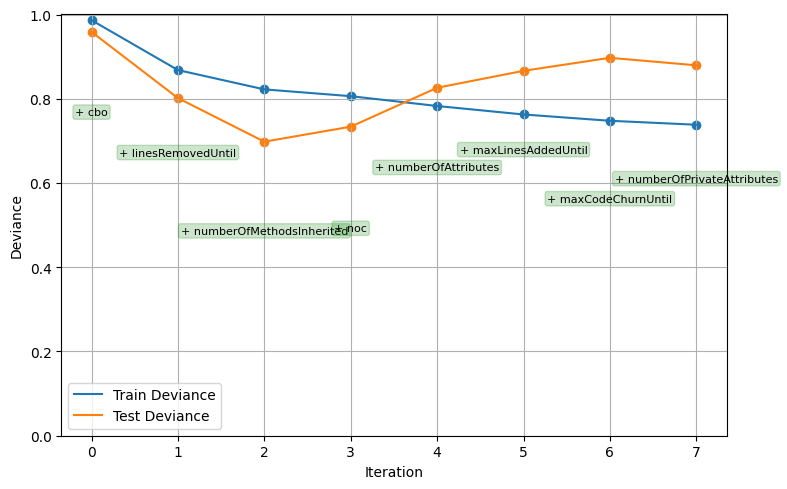

In [364]:
# plot the deviance history
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(train_deviance_history, label='Train Deviance')
ax.plot(test_deviance_history, label='Test Deviance')

ax.scatter(range(len(train_deviance_history)), train_deviance_history)
ax.scatter(range(len(test_deviance_history)), test_deviance_history)

ax.set_xlabel('Iteration')
ax.set_ylabel('Deviance')

ax.grid(True)
ax.set_ylim(0, None)

# for the next plot
number_of_steps = len(event_history)

for idx, (feature, action) in enumerate(event_history):
    color = 'green' if action == 'add' else 'red'
    ax.text(
        idx, 
        min(train_deviance_history[idx], test_deviance_history[idx]) - .25 + np.random.rand()*0.2, 
        f'{"+" if action == "add" else "-"} {feature.replace(":", "")}',
        ha='center', va='top', fontsize=8, rotation=0,
        bbox=dict(facecolor=color, alpha=0.2, boxstyle='round,pad=0.2', edgecolor=color)
    )
ax.legend()
fig.tight_layout()

plt.savefig(f'{FOLDER_EXPORTS}/poisson_regression_stepwise_deviance_history_aic{"_log" if use_log_transformed else ""}.png')
plt.show()

## When using BIC for Scoring

In [365]:
# reset the history
train_deviance_history = []
test_deviance_history = []
event_history = []

# stepwise on training set
stepwise_features_bic, stepwise_model_bic = forward_stepwise_poisson(X_train, y_train, use_bic=True)

print("Selected features (stepwise):")
print(stepwise_features_bic)
print(stepwise_model_bic.summary())

Iteration 0
Iteration: 0, Train deviance: 0.986586, Test deviance: 0.958791
Iteration 1
Iteration: 1, Train deviance: 0.868179, Test deviance: 0.801668
Iteration 2
Iteration: 2, Train deviance: 0.822312, Test deviance: 0.698078
Iteration 3
Selected features (stepwise):
['cbo', 'linesRemovedUntil:', 'numberOfMethodsInherited']
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   bugs   No. Observations:                  217
Model:                            GLM   Df Residuals:                      213
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -192.20
Date:                Sun, 01 Feb 2026   Deviance:                       178.44
Time:                        17:55:04   Pearson chi2:                     216.
No. Iterations:                     6   

/Users/felix/Desktop/git_repos/Statistical-Learning-/sheet-01/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(
/Users/felix/Desktop/git_repos/Statistical-Learning-/sheet-01/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using 

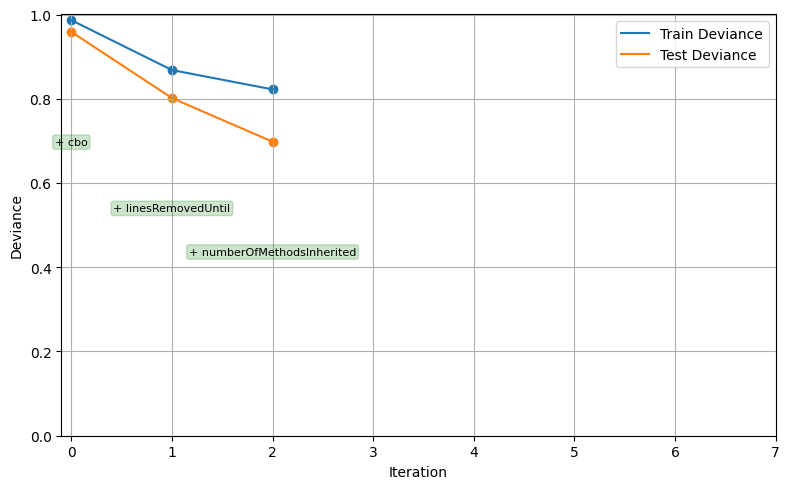

In [366]:
# plot the deviance history
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(train_deviance_history, label='Train Deviance')
ax.plot(test_deviance_history, label='Test Deviance')

ax.scatter(range(len(train_deviance_history)), train_deviance_history)
ax.scatter(range(len(test_deviance_history)), test_deviance_history)

ax.set_xlabel('Iteration')
ax.set_ylabel('Deviance')

ax.grid(True)
ax.set_ylim(0, None)
if len(event_history) < number_of_steps:
    ax.set_xlim(None, number_of_steps-1)

for idx, (feature, action) in enumerate(event_history):
    color = 'green' if action == 'add' else 'red'
    ax.text(
        idx, 
        min(train_deviance_history[idx], test_deviance_history[idx]) - 0.25, 
        f'{"+" if action == "add" else "-"} {feature.replace(":", "")}',
        ha='center', va='top', fontsize=8, rotation=0,
        bbox=dict(facecolor=color, alpha=0.2, boxstyle='round,pad=0.2', edgecolor=color)
    )

ax.legend()
fig.tight_layout()
plt.savefig(f'{FOLDER_EXPORTS}/poisson_regression_stepwise_deviance_history_bic{"_log" if use_log_transformed else ""}.png')
plt.show()

In [367]:
print(stepwise_features_bic)
if not use_log_transformed:
    print('Using min_val=None')
    print(analyze_prediction_increase_parameters(stepwise_model_bic, stepwise_features_bic, features, scaler_normalized, _min_add=None))
else:
    print('Using min_val')
    print(analyze_prediction_increase_parameters(stepwise_model_bic, stepwise_features_bic, features, scaler_log_transformed, _min_add=min_val))

['cbo', 'linesRemovedUntil:', 'numberOfMethodsInherited']
Using min_val
[0.33600697 1.29458157 1.79536676]


/var/folders/65/zrtbfn791rn640f82t5dqybm0000gn/T/ipykernel_31683/4275330526.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ratios.append(np.exp(_model.params[fid] * delta))


In [369]:
# Mean deviation found
print('Train deviance:', train_deviance_history[-1])
print('Test deviance:', test_deviance_history[-1])

Train deviance: 0.8223124733984547
Test deviance: 0.6980782248498346


# Poisson Regression with $L_1$-Lasso

When using `pyglmnet` for the poisson regression, we observed that using the default learning rate did not converge. However, using a learning rate of $1\cdot 10^{-4}$ instead of $2\cdot 10^{-2}$ allows for convergence for some cases. Therefore, we implement Poisson regression in Pytorch, as it allows us to use hardware accelaration as we need to run the code for a large number of steps.

Using pytorch, we are able to speed up the process from minutes to seconds.

In [15]:
class PoissonRegression(nn.Module):
    def __init__(self, n_features: int, learning_rate: float, reg_lambda: float):
        super(PoissonRegression, self).__init__()

        self.linear = nn.Linear(n_features, 1, bias=False)
        self.learning_rate = learning_rate
        self.reg_lambda = reg_lambda

        self.weight_history = []

    def log_likelihood(self, X: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        # add constant term to X
        # X = torch.cat([torch.ones(X.shape[0], 1).to(X.device), X], dim=1)
        return torch.sum(
            y * self.linear(X) - torch.exp(self.linear(X))
        )

    def L1_lasso(self) -> torch.Tensor:
        return self.reg_lambda * torch.sum(torch.abs(self.linear.weight))

    def fit(self, X: torch.Tensor, y: torch.Tensor, max_epochs: int = 1_000, verbose: bool = False, save_weight_history: bool = False):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)

        # magnitude_weights = []
        previous_weight = torch.zeros_like(self.linear.weight).to(X.device)

        for epoch in (pbar := tqdm(range(max_epochs), desc="Epoch", total=max_epochs, disable=not verbose)):
            optimizer.zero_grad()

            log_likelihood = self.log_likelihood(X, y)
            l1_lasso = self.L1_lasso()

            loss = -log_likelihood + l1_lasso

            loss.backward()
            optimizer.step()

            if save_weight_history:
                self.weight_history.append(self.linear.weight.detach().cpu().numpy())

            if (weight_diff := torch.sum(torch.abs(previous_weight - self.linear.weight))) < 1e-6:
                break
            else:
                previous_weight = self.linear.weight.detach().clone()
            pbar.set_postfix(loss=loss.detach().cpu().item(), gradient_norm=weight_diff.detach().cpu().item())

    def predict(self, X: torch.Tensor) -> torch.Tensor:
        # print(self.linear(X))
        return torch.exp(self.linear(X))

    def compute_deviance(self, X_train: torch.Tensor, y_train: torch.Tensor, X_test: torch.Tensor, y_test: torch.Tensor) -> tuple[float, float]:
        with torch.no_grad():
            y_train_pred = self.predict(X_train)
            y_test_pred = self.predict(X_test)

        train_deviance = mean_poisson_deviance(y_train.detach().cpu().numpy(), y_train_pred.detach().cpu().numpy())
        test_deviance = mean_poisson_deviance(y_test.detach().cpu().numpy(), y_test_pred.detach().cpu().numpy())

        return train_deviance, test_deviance

In [183]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
# elif torch.backends.mps.is_available():
#     device = 'mps'

print(f"Using device: {device}")

Using device: cpu


In [184]:
# use log-transformed data
X_train = train_df[features].values
y_train = train_df["bugs"].values

X_test  = test_df[features].values
y_test  = test_df["bugs"].values

# convert to tensors
X_train = torch.from_numpy(X_train).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
X_test = torch.from_numpy(X_test).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

# add constant term to X
X_train = torch.cat([torch.ones(X_train.size(0), 1, device=X_train.device), X_train], dim=1)
X_test = torch.cat([torch.ones(X_test.size(0), 1, device=X_test.device), X_test], dim=1)

poisson_model = PoissonRegression(n_features=X_train.shape[1], learning_rate=1e-4, reg_lambda=2 * 1e-1).to(device)
poisson_model.log_likelihood(X_train, y_train)

tensor(-51151.8281, grad_fn=<SumBackward0>)

In [185]:
magnitudes = poisson_model.fit(X_train, y_train, max_epochs=20_000, verbose=True)

Epoch:  31%|███▏      | 6279/20000 [00:07<00:16, 832.03it/s, gradient_norm=0.000174, loss=4.58e+4]


KeyboardInterrupt: 

In [180]:
poisson_model.compute_deviance(X_train, y_train, X_test, y_test)

(1.8805794715881348, 1.686881422996521)

### Using Pyglmnet

You can change the `use_log_transformed` here, but do NOT change it for the computation of the history of the coefficients

In [329]:
use_log_transformed = True

if use_log_transformed:
    X_train = train_df[features].values
    y_train = train_df["bugs"].values

    X_test  = test_df[features].values
    y_test  = test_df["bugs"].values
else:
    # code for running on the normalized but not log transformed data
    X_train = train_df_normalized[features].values
    y_train = train_df_normalized["bugs"].values

    X_test  = test_df_normalized[features].values
    y_test  = test_df_normalized["bugs"].values

    # scaler = StandardScaler()
    # X_train = scaler.fit_transform(X_train)
    # X_test  = scaler.transform(X_test)

lambdas = np.logspace(-10, -1, 100)
# lambdas = np.linspace(np.log(1e-4), np.log(0), 100)
# print(lambdas)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_lambda = None
best_score = np.inf

poisson_deviance_means_train_train = []
poisson_deviance_means_train_test = []
poisson_deviance_means_test = []

poisson_deviance_stds_train_train = []
poisson_deviance_stds_train_test = []
poisson_deviance_stds_test = []

for lam in tqdm(lambdas, desc="Lambda", total=len(lambdas)):
    fold_scores_train_train = []
    fold_scores_train_test = []
    fold_scores_test = []

    for tr_idx, val_idx in kf.split(X_train):
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            warnings.filterwarnings("ignore", category=UserWarning)
            model = GLM(
                distr="poisson",
                alpha=1.0,
                reg_lambda=lam,
                learning_rate=1e-3,
                max_iter=10_000 
            )
            model.fit(X_train[tr_idx], y_train[tr_idx])

        y_train_pred = model.predict(X_train[tr_idx])
        y_val_pred = model.predict(X_train[val_idx])
        y_test_pred = model.predict(X_test)

        fold_scores_train_train.append(mean_poisson_deviance(y_train[tr_idx], y_train_pred))
        fold_scores_train_test.append(mean_poisson_deviance(y_train[val_idx], y_val_pred))
        fold_scores_test.append(mean_poisson_deviance(y_test, y_test_pred))

    # compute the means 
    poisson_deviance_means_train_train.append(np.mean(fold_scores_train_train))
    poisson_deviance_means_train_test.append(np.mean(fold_scores_train_test))
    poisson_deviance_means_test.append(np.mean(fold_scores_test))

    # compute the stds
    poisson_deviance_stds_train_train.append(np.std(fold_scores_train_train))
    poisson_deviance_stds_train_test.append(np.std(fold_scores_train_test))
    poisson_deviance_stds_test.append(np.std(fold_scores_test))

poisson_deviance_means_train_train = np.array(poisson_deviance_means_train_train)
poisson_deviance_means_train_test = np.array(poisson_deviance_means_train_test)
poisson_deviance_means_test = np.array(poisson_deviance_means_test)

poisson_deviance_stds_train_train = np.array(poisson_deviance_stds_train_train)
poisson_deviance_stds_train_test = np.array(poisson_deviance_stds_train_test)
poisson_deviance_stds_test = np.array(poisson_deviance_stds_test)

Lambda: 100%|██████████| 100/100 [02:25<00:00,  1.45s/it]


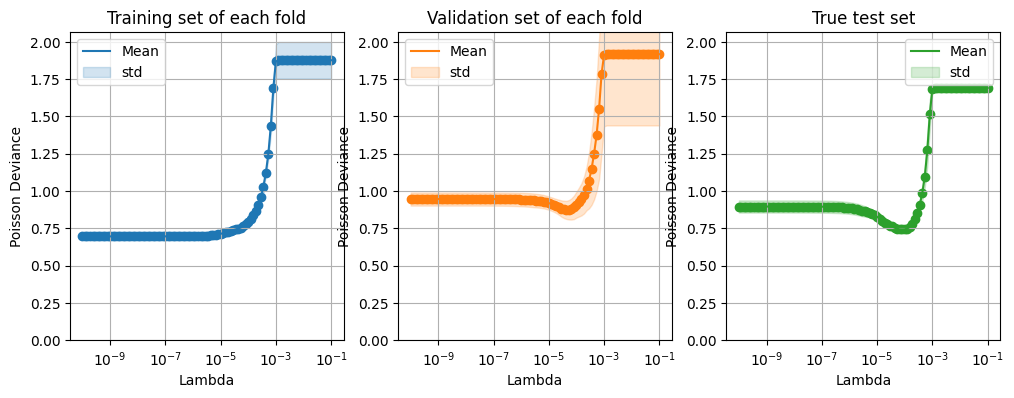

In [330]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

colors = plt.get_cmap('tab10').colors
ax[ 0].plot(lambdas, poisson_deviance_means_train_train, label='Mean', color=colors[0])
ax[1].plot(lambdas, poisson_deviance_means_train_test, label='Mean', color=colors[1])
ax[2].plot(lambdas, poisson_deviance_means_test, label='Mean', color=colors[2])

ax[0].fill_between(lambdas, poisson_deviance_means_train_train - poisson_deviance_stds_train_train, poisson_deviance_means_train_train + poisson_deviance_stds_train_train, alpha=0.2, color=colors[0], label='std')
ax[1].fill_between(lambdas, poisson_deviance_means_train_test - poisson_deviance_stds_train_test, poisson_deviance_means_train_test + poisson_deviance_stds_train_test, alpha=0.2, color=colors[1], label='std')
ax[2].fill_between(lambdas, poisson_deviance_means_test - poisson_deviance_stds_test, poisson_deviance_means_test + poisson_deviance_stds_test, alpha=0.2, color=colors[2], label='std')

ax[0].scatter(lambdas, poisson_deviance_means_train_train, color=colors[0])
ax[1].scatter(lambdas, poisson_deviance_means_train_test, color=colors[1])
ax[2].scatter(lambdas, poisson_deviance_means_test, color=colors[2])

for i in range(3):
    ax[i].set_xscale('log')
    ax[i].set_xlabel('Lambda')
    ax[i].set_ylabel('Poisson Deviance')
    ax[i].grid(True)
    ax[i].legend()

    ax[i].set_ylim(0, None)

for i in range(1, 3):
    ax[i].set_ylim(ax[0].get_ylim())

ax[0].set_title('Training set of each fold')
ax[1].set_title('Validation set of each fold')
ax[2].set_title('True test set')


plt.savefig(f'{FOLDER_EXPORTS}/poisson_regression_lasso_deviance_vs_lambda_{"no_log_transform" if not use_log_transformed else "log_transform"}.png')
plt.show()

## History of coefficients

In [331]:
# use_log_transformed = True

if use_log_transformed:
    X_train = train_df[features].values
    y_train = train_df["bugs"].values

    X_test  = test_df[features].values
    y_test  = test_df["bugs"].values
else:
    # code for running on the normalized but not log transformed data
    X_train = train_df_normalized[features].values
    y_train = train_df_normalized["bugs"].values

    X_test  = test_df_normalized[features].values
    y_test  = test_df_normalized["bugs"].values

# code for running on the normalized but not log transformed data
# X_train = train_df_raw[features].values
# y_train = train_df_raw["bugs"].values

# X_test  = test_df_raw[features].values
# y_test  = test_df_raw["bugs"].values

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test  = scaler.transform(X_test)

coefficients_beta0_means = []
coefficients_beta_means = []

coefficients_beta0_stds = []
coefficients_beta_stds = []

lambdas = np.logspace(-10, -1, 100)
# lambdas = np.linspace(np.log(1e-4), np.log(0), 100)
# print(lambdas)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_lambda = None
best_score = np.inf

poisson_deviance_means_train_train = []
poisson_deviance_means_train_test = []
poisson_deviance_means_test = []

poisson_deviance_stds_train_train = []
poisson_deviance_stds_train_test = []
poisson_deviance_stds_test = []

for lam in tqdm(lambdas, desc="Lambda", total=len(lambdas)):
    fold_scores_train_train = []
    fold_scores_train_test = []
    fold_scores_test = []

    coefficients_beta0 = []
    coefficients_beta = []

    for tr_idx, val_idx in kf.split(X_train):
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            warnings.filterwarnings("ignore", category=UserWarning)
            model = GLM(
                distr="poisson",
                alpha=1.0,
                reg_lambda=lam,
                learning_rate=1e-3,  # increased the learning rate to obtain the results a little bit faster
                max_iter=10_000  
            )
            model.fit(X_train[tr_idx], y_train[tr_idx])

        y_train_pred = model.predict(X_train[tr_idx])
        y_val_pred = model.predict(X_train[val_idx])
        y_test_pred = model.predict(X_test)

        fold_scores_train_train.append(mean_poisson_deviance(y_train[tr_idx], y_train_pred))
        fold_scores_train_test.append(mean_poisson_deviance(y_train[val_idx], y_val_pred))
        fold_scores_test.append(mean_poisson_deviance(y_test, y_test_pred))

        coefficients_beta0.append(model.beta0_)
        coefficients_beta.append(model.beta_)

    coefficients_beta0 = np.array(coefficients_beta0)
    coefficients_beta = np.array(coefficients_beta)

    coefficients_beta0_means.append(coefficients_beta0.mean(axis=0))
    coefficients_beta_means.append(coefficients_beta.mean(axis=0))

    coefficients_beta0_stds.append(coefficients_beta0.std(axis=0))
    coefficients_beta_stds.append(coefficients_beta.std(axis=0))

    # compute the means 
    poisson_deviance_means_train_train.append(np.mean(fold_scores_train_train))
    poisson_deviance_means_train_test.append(np.mean(fold_scores_train_test))
    poisson_deviance_means_test.append(np.mean(fold_scores_test))

    # compute the stds
    poisson_deviance_stds_train_train.append(np.std(fold_scores_train_train))
    poisson_deviance_stds_train_test.append(np.std(fold_scores_train_test))
    poisson_deviance_stds_test.append(np.std(fold_scores_test))

poisson_deviance_means_train_train = np.array(poisson_deviance_means_train_train)
poisson_deviance_means_train_test = np.array(poisson_deviance_means_train_test)
poisson_deviance_means_test = np.array(poisson_deviance_means_test)

poisson_deviance_stds_train_train = np.array(poisson_deviance_stds_train_train)
poisson_deviance_stds_train_test = np.array(poisson_deviance_stds_train_test)
poisson_deviance_stds_test = np.array(poisson_deviance_stds_test)

coefficients_beta0_means = np.array(coefficients_beta0_means)
coefficients_beta_means = np.array(coefficients_beta_means)

coefficients_beta0_stds = np.array(coefficients_beta0_stds)
coefficients_beta_stds = np.array(coefficients_beta_stds)

Lambda: 100%|██████████| 100/100 [02:29<00:00,  1.49s/it]


In [342]:
# get the coefficients
best_lambda = lambdas[np.argmin(poisson_deviance_means_test)]
model_best = GLM(
    distr="poisson",
    alpha=1.0,
    reg_lambda=best_lambda,
    learning_rate=1e-3,  # increased the learning rate to obtain the results a little bit faster
    max_iter=10_000  
)
model_best.fit(X_train, y_train)

model_best.beta_

/Users/felix/Desktop/git_repos/Statistical-Learning-/sheet-01/.venv/lib/python3.13/site-packages/pyglmnet/pyglmnet.py:863: UserWarning: Reached max number of iterations without convergence.
  warnings.warn(


array([ 0.23794205,  0.05375149, -0.        ,  0.05169275, -0.        ,
       -0.        , -0.        ,  0.03600469, -0.        , -0.        ,
        0.        , -0.        ,  0.        , -0.        ,  0.00423815,
        0.12909216, -0.        ,  0.20921246,  0.14067536,  0.02905883,
        0.04975151,  0.09838604, -0.        ,  0.04798387, -0.        ,
        0.15063927, -0.        , -0.        , -0.        , -0.        ,
       -0.        ,  0.10133439])

In [ ]:
print(stepwise_features_bic)
if not use_log_transformed:
    print('Using min_val=None')
    print(analyze_prediction_increase_parameters(model_best, features, features, scaler_normalized, _min_add=None))
else:
    print('Using min_val')
    print(analyze_prediction_increase_parameters(model_best, features, features, scaler_normalized, _min_add=min_val))

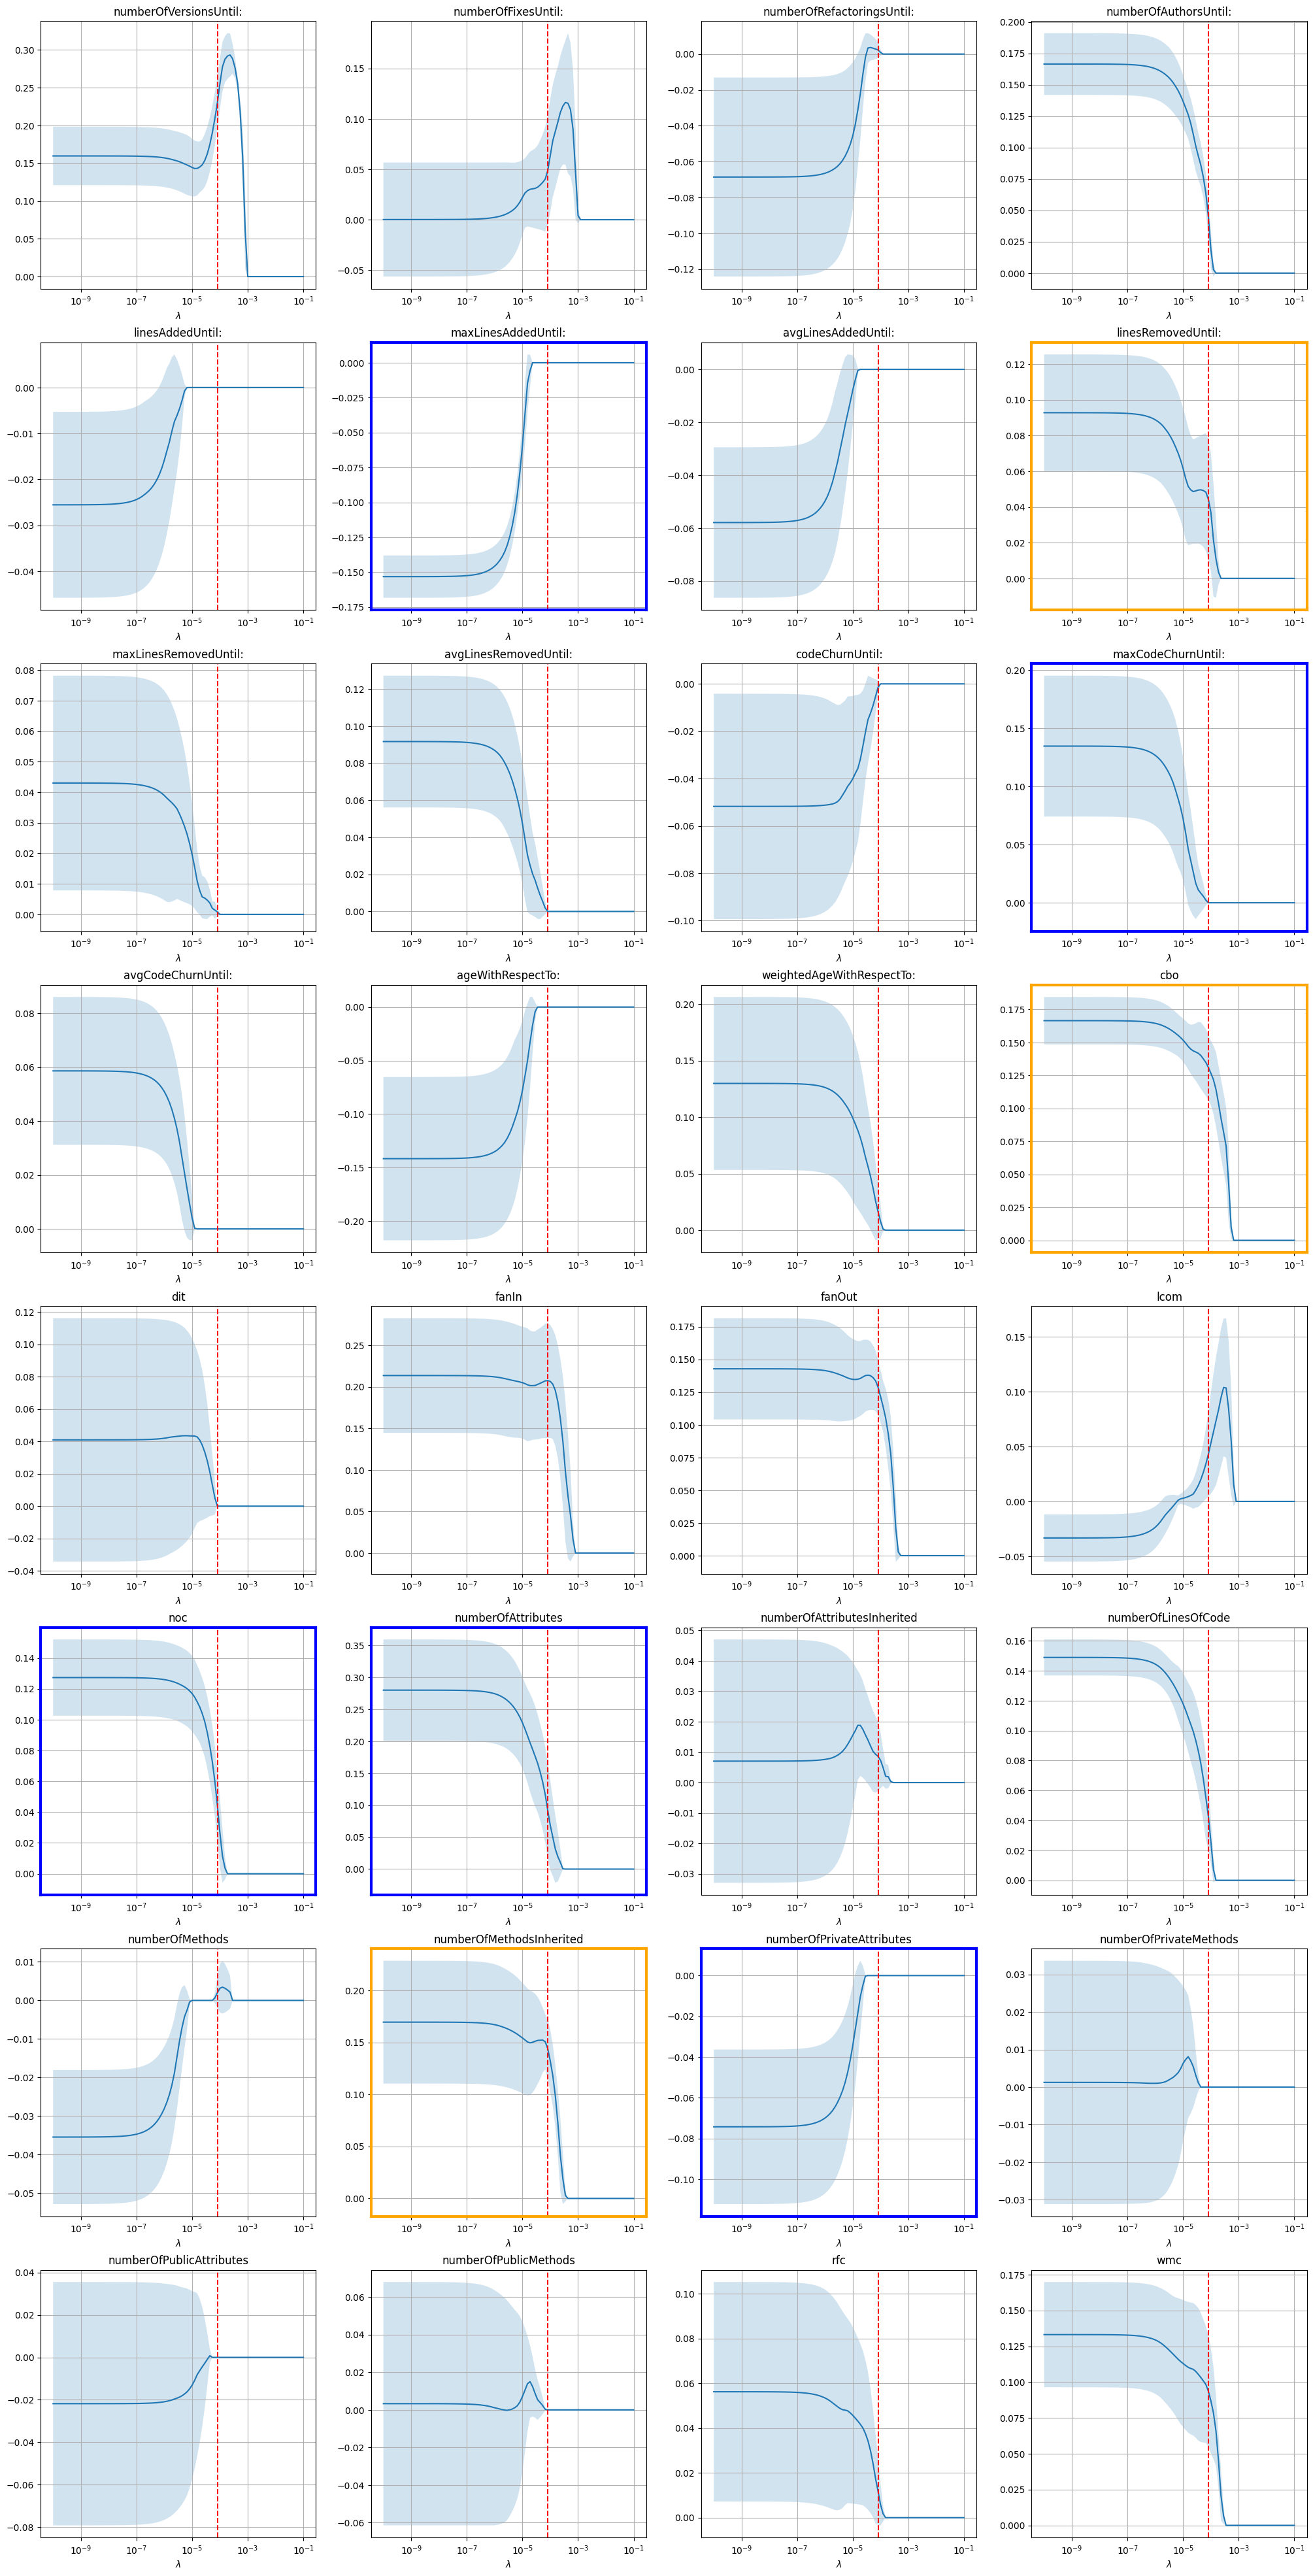

In [332]:
# plot each of the 32 coefficients in a separate plot 
fig, axs = plt.subplots(8, 4, figsize=(25, 50))

# get lambda with the lowest test deviance 
best_lambda = lambdas[np.argmin(poisson_deviance_means_test)]

for i in range(32):
    ax = axs[i // 4, i % 4]
    ax.plot(lambdas, coefficients_beta_means[:, i], label='mean')
    ax.fill_between(lambdas, coefficients_beta_means[:, i] - coefficients_beta_stds[:, i], coefficients_beta_means[:, i] + coefficients_beta_stds[:, i], alpha=0.2)
    ax.set_xscale('log')
    ax.set_xlabel('$\\lambda$')
    # ax.set_ylabel('Coefficient')
    ax.set_title(df.columns[i])
    # ax.legend()
    ax.grid(True)

    ax.axvline(best_lambda, color='red', linestyle='--', label='Best Lambda')

    if df.columns[i] in stepwise_features_bic:
        for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_color('orange')
    elif df.columns[i] in stepwise_features_aic:
        for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_color('blue')

fig.savefig(f'{FOLDER_EXPORTS}/poisson_regression_lasso_coefficients_{"log_transform" if use_log_transformed else "no_log_transform"}.png')

In [333]:
print(f'Best found lambda is: {best_lambda} which achieves a deviance of:')
print(f'\tTrain Deviance: {poisson_deviance_means_train_train[np.argmin(poisson_deviance_means_test)]}')
print(f'\tTest Deviance: {poisson_deviance_means_test[np.argmin(poisson_deviance_means_test)]}')

Best found lambda is: 8.111308307896872e-05 which achieves a deviance of:
	Train Deviance: 0.7776128599546807
	Test Deviance: 0.742517075853103


In [334]:
1e-4

0.0001

### Using Pytorch

In [27]:
# use log-transformed data
X_train = train_df[features].values
y_train = train_df["bugs"].values

X_test  = test_df[features].values
y_test  = test_df["bugs"].values

# convert to tensors
X_train = torch.from_numpy(X_train).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
X_test = torch.from_numpy(X_test).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

# add constant term to X
X_train = torch.cat([torch.ones(X_train.size(0), 1, device=X_train.device), X_train], dim=1)
X_test = torch.cat([torch.ones(X_test.size(0), 1, device=X_test.device), X_test], dim=1)

NameError: name 'device' is not defined

In [168]:
lam = 2 * 1e-1
model = PoissonRegression(n_features=X_train.shape[1], learning_rate=1e-4, reg_lambda=lam).to(device)
model.fit(X_train, y_train, max_epochs=20_000, verbose=True, save_weight_history=True)

deviation_train, deviation_test = model.compute_deviance(X_train, y_train, X_test, y_test)
print(f'With lambda: {lam}, we got:')
print(f'\tTrain Deviance: {deviation_train}')
print(f'\tTest Deviance: {deviation_test}')

Epoch: 100%|██████████| 20000/20000 [00:51<00:00, 391.56it/s, gradient_norm=10.7, loss=4.58e+4]  


With lambda: 0.2, we got:
	Train Deviance: 1.880604863166809
	Test Deviance: 1.686904788017273


In [ ]:
model.weight_history

# Logistic Regression

Re-using the same code as above

## Stepwise Search

In [419]:

# add the binary response variable
train_df["bugbin"] = (train_df["bugs"] >= 1).astype(int)
test_df["bugbin"]  = (test_df["bugs"] >= 1).astype(int)

X_cols = [c for c in train_df.columns if c != "bugs" and c != "bugbin"]
print(len(X_cols), 'features found')

use_log_transformed = True

if use_log_transformed:
    X_train = train_df[X_cols]
    y_train = train_df["bugbin"]

    X_test  = test_df[X_cols]
    y_test  = test_df["bugbin"]
else:
    X_train = train_df_normalized[X_cols]
    y_train = train_df["bugbin"]

    X_test  = test_df_normalized[X_cols]
    y_test  = test_df["bugbin"]

def logistic_aic(X, y, use_bic=False):
    try:
        with warnings.catch_warnings():  # the bic warning is not important
            warnings.simplefilter("ignore", category=FutureWarning)
            warnings.simplefilter("ignore", category=PerfectSeparationWarning)
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            X_ = sm.add_constant(X, has_constant="add")
            model = sm.Logit(y, X_)
            # with warnings.catch_warnings():
            res = model.fit()
        if use_bic:
            return res.bic, res
        else:
            return res.aic, res
    except Exception as e:
        return np.inf, None


def evaluate_logistic_stepwise(model, _X_train, _y_train, _X_test, _y_test, _features, _iteration=None):
    prediction_train = np.array(model.predict(sm.add_constant(_X_train[_features], has_constant="add")) > 0.5).astype(int)
    prediction_test  = np.array(model.predict(sm.add_constant(_X_test[_features], has_constant="add")) > 0.5).astype(int)

    train_accuracy = accuracy_score(_y_train, prediction_train)
    test_accuracy  = accuracy_score(_y_test, prediction_test)

    if _iteration is not None:
        print(f"Iteration: {_iteration}, Train accuracy: {train_accuracy:.6f}, Test accuracy: {test_accuracy:.6f}")
    else:
        print(f"Train accuracy: {train_accuracy:.6f}, Test accuracy: {test_accuracy:.6f}")

    return train_accuracy, test_accuracy

train_accuracy_history = []
test_accuracy_history = []
event_history = []

def forward_stepwise_logistic(X, y, use_bic=False):
    remaining = list(X.columns)
    selected = []
    current_aic = np.inf
    # current_aic_test = np.inf
    best_aic_test = np.inf
    best_model = None

    keep_going = True
    iteration = 0

    while keep_going:
        print('Iteration', iteration)
        aic_candidates = []

        new_features = [c for c in list(X.columns) if c not in selected]

        # forward selection
        for c in new_features:
            aic, _ = logistic_aic(X[selected + [c]], y, use_bic=use_bic)
            aic_candidates.append((aic, c, None))

        # backward selection
        for c in selected:
            features = [_c for _c in list(X.columns) if _c != c and c in selected]
            aic, _ = logistic_aic(X[features], y, use_bic=use_bic)
            aic_candidates.append((aic, None, c))

        # hybrid selection
        # for c_add in new_features:
        #     for c_remove in selected:
        #         features = [c for c in list(X.columns) if (c in selected and not c == c_remove) or c == c_add ]
        #         aic, _ = poisson_aic(X[features], y, use_bic=use_bic)
        #         aic_candidates.append((aic, c_add, c_remove))

        aic_candidates.sort(key=lambda x: x[0], reverse=False)
        best_new_aic, best_candidate_add, best_candidate_remove = aic_candidates[0]

        # aic_test, _ = poisson_aic(test[selected], y)

        if best_new_aic < current_aic:
            if best_candidate_add is not None:
                selected.append(best_candidate_add)
                event_history.append((best_candidate_add, 'add'))
                
            if best_candidate_remove is not None:
                selected.remove(best_candidate_remove)
                event_history.append((best_candidate_remove, 'remove'))

            current_aic = best_new_aic
            _, best_model = logistic_aic(X[selected], y, use_bic=use_bic)
            
            train_accuracy, test_accuracy = evaluate_logistic_stepwise(best_model, X_train, y_train, X_test, y_test, selected, iteration)
            train_accuracy_history.append(train_accuracy)
            test_accuracy_history.append(test_accuracy)

            # print(len(train_deviance_history), len(test_deviance_history), len(event_history))
        else:
            keep_going = False
            break

        iteration += 1


    return selected, best_model

32 features found


### With AIC

In [420]:
# reset the history
train_accuracy_history = []
test_accuracy_history = []
event_history = []

# stepwise on training set
stepwise_features_aic_logistic, stepwise_model_aic_logistic = forward_stepwise_logistic(X_train, y_train, use_bic=False)

Iteration 0
Optimization terminated successfully.
         Current function value: 0.533208
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.602021
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.666153
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.605480
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.549192
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.570527
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.584121
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.542275
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.562059
         Iterations 5
Optimization terminated successfully.
         Current function value:

In [421]:
print("Selected features (stepwise):")
print(stepwise_features_aic_logistic)
print(stepwise_model_aic_logistic.summary())

train_accuracy, test_accuracy = evaluate_logistic_stepwise(stepwise_model_aic_logistic, X_train, y_train, X_test, y_test, stepwise_features_aic_logistic)

Selected features (stepwise):
['wmc', 'numberOfVersionsUntil:', 'numberOfRefactoringsUntil:', 'noc', 'dit', 'numberOfAttributes']
                           Logit Regression Results                           
Dep. Variable:                 bugbin   No. Observations:                  217
Model:                          Logit   Df Residuals:                      210
Method:                           MLE   Df Model:                            6
Date:                Sun, 01 Feb 2026   Pseudo R-squ.:                  0.3448
Time:                        18:39:37   Log-Likelihood:                -95.476
converged:                       True   LL-Null:                       -145.71
Covariance Type:            nonrobust   LLR p-value:                 1.999e-19
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -0.7265      0.196

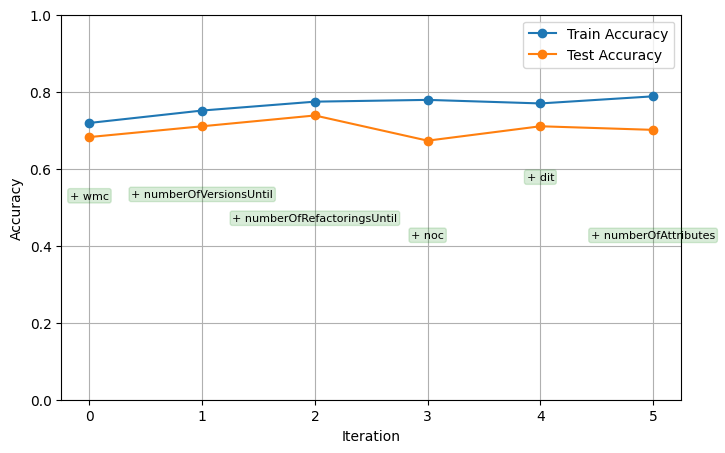

In [422]:
# plot the deviance history
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(train_accuracy_history, label='Train Accuracy', marker='o')
ax.plot(test_accuracy_history, label='Test Accuracy', marker='o')

ax.set_xlabel('Iteration')
ax.set_ylabel('Accuracy')

ax.grid(True)
ax.set_ylim(0, 1)

for idx, (feature, action) in enumerate(event_history):
    color = 'green' if action == 'add' else 'red'
    ax.text(
        idx, 
        # min(train_accuracy_history[idx], test_accuracy_history[idx]) - .1 + np.random.rand()*0.03, 
        min(train_accuracy_history[idx], test_accuracy_history[idx]) - .3 + np.random.rand()*0.2, 
        f'{"+" if action == "add" else "-"} {feature.replace(":", "")}',
        ha='center', va='top', fontsize=8, rotation=0,
        bbox=dict(facecolor=color, alpha=0.15, boxstyle='round,pad=0.2', edgecolor=color)
    )
ax.legend()

# ax.set_ylim(0, 1)

plt.savefig(f'{FOLDER_EXPORTS}/logistic_regression_stepwise_accuracy_history_aic_{"log_transform" if use_log_transformed else "no_log_transform"}.png')
plt.show()

### Selecting using BIC

In [423]:
# reset the history
train_accuracy_history = []
test_accuracy_history = []
event_history = []

# stepwise on training set
stepwise_features_bic_logistic, stepwise_model_bic_logistic = forward_stepwise_logistic(X_train, y_train, use_bic=True)

Iteration 0
Optimization terminated successfully.
         Current function value: 0.533208
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.602021
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.666153
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.605480
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.549192
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.570527
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.584121
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.542275
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.562059
         Iterations 5
Optimization terminated successfully.
         Current function value:

In [424]:
print("Selected features (stepwise):")
print(stepwise_features_bic_logistic)
print(stepwise_model_bic_logistic.summary())

train_accuracy, test_accuracy = evaluate_logistic_stepwise(stepwise_model_bic_logistic, X_train, y_train, X_test, y_test, stepwise_features_bic_logistic)

Selected features (stepwise):
['wmc', 'numberOfVersionsUntil:', 'numberOfRefactoringsUntil:']
                           Logit Regression Results                           
Dep. Variable:                 bugbin   No. Observations:                  217
Model:                          Logit   Df Residuals:                      213
Method:                           MLE   Df Model:                            3
Date:                Sun, 01 Feb 2026   Pseudo R-squ.:                  0.2903
Time:                        18:39:39   Log-Likelihood:                -103.41
converged:                       True   LL-Null:                       -145.71
Covariance Type:            nonrobust   LLR p-value:                 3.146e-18
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -0.6210      0.180     -3.452      0.001      -0.974  

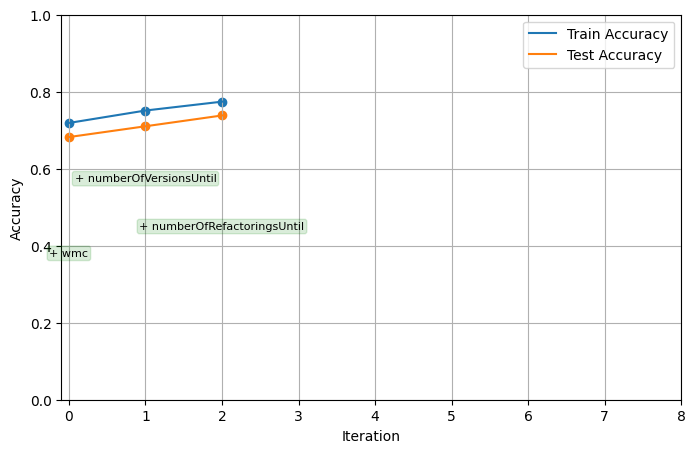

In [425]:
# plot the deviance history
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(train_accuracy_history, label='Train Accuracy')
ax.plot(test_accuracy_history, label='Test Accuracy')

ax.scatter(range(len(train_accuracy_history)), train_accuracy_history)
ax.scatter(range(len(test_accuracy_history)), test_accuracy_history)

ax.set_xlabel('Iteration')
ax.set_ylabel('Accuracy')

ax.grid(True)
ax.set_ylim(0, 1)

if len(event_history) < number_of_steps:
    ax.set_xlim(None, number_of_steps)

for idx, (feature, action) in enumerate(event_history):
    color = 'green' if action == 'add' else 'red'
    ax.text(
        idx, 
        min(train_accuracy_history[idx], test_accuracy_history[idx]) - .3 + np.random.rand()*0.2, 
        f'{"+" if action == "add" else "-"} {feature.replace(":", "")}',
        ha='center', va='top', fontsize=8, rotation=0,
        bbox=dict(facecolor=color, alpha=0.15, boxstyle='round,pad=0.2', edgecolor=color)
    )
ax.legend()

plt.savefig(f'{FOLDER_EXPORTS}/logistic_regression_stepwise_accuracy_history_bic_{"log_transform" if use_log_transformed else "no_log_transform"}.png')
plt.show()

In [426]:
print(stepwise_features_bic)
if not use_log_transformed:
    print('Using min_val=None')
    print(analyze_prediction_increase_parameters(stepwise_model_bic_logistic, stepwise_features_bic_logistic, features, scaler_normalized, _min_add=None))
else:
    print('Using min_val')
    print(analyze_prediction_increase_parameters(stepwise_model_bic_logistic, stepwise_features_bic_logistic, features, scaler_log_transformed, _min_add=min_val))

['cbo', 'linesRemovedUntil:', 'numberOfMethodsInherited']
Using min_val
[ 0.64240555  2.11984211 14.03890927]


/var/folders/65/zrtbfn791rn640f82t5dqybm0000gn/T/ipykernel_31683/4275330526.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ratios.append(np.exp(_model.params[fid] * delta))


## $L_1$-Lasso

In [593]:
use_log_transformed = False

if use_log_transformed:
    X_train = train_df[features].values
    y_train = train_df["bugbin"].values

    X_test  = test_df[features].values
    y_test  = test_df["bugbin"].values
else:
    # code for running on the normalized but not log transformed data
    X_train = train_df_normalized[features].values
    y_train = train_df["bugbin"].values

    X_test  = test_df_normalized[features].values
    y_test  = test_df["bugbin"].values

    # scaler = StandardScaler()
    # X_train = scaler.fit_transform(X_train)
    # X_test  = scaler.transform(X_test)

lambdas = np.logspace(-10, 5, 100)
# lambdas = np.linspace(np.log(1e-4), np.log(0), 100)
# print(lambdas)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_lambda = None
best_score = np.inf

poisson_deviance_means_train_train = []
poisson_deviance_means_train_test = []
poisson_deviance_means_test = []

poisson_deviance_stds_train_train = []
poisson_deviance_stds_train_test = []
poisson_deviance_stds_test = []

for lam in tqdm(lambdas, desc="Lambda", total=len(lambdas)):
    fold_scores_train_train = []
    fold_scores_train_test = []
    fold_scores_test = []


    for tr_idx, val_idx in kf.split(X_train):
        with warnings.catch_warnings():
            # warnings.filterwarnings("ignore", category=ConvergenceWarning)
            # warnings.filterwarnings("ignore", category=UserWarning)
            model = LogisticRegression(
                penalty='l1',
                # l1_ratio=1.0,
                C=1/lam,
                solver='liblinear',
                max_iter=1_000
            )
            # model.fit(X_train[tr_idx], y_train[tr_idx])
            model.fit(X_train[tr_idx], y_train[tr_idx])
            # model = GLM(
            #     distr="poisson",
            #     alpha=1.0,
            #     reg_lambda=lam,
            #     learning_rate=1e-3,
            #     max_iter=10_000 
            # )
            # model.fit(X_train[tr_idx], y_train[tr_idx])

        y_train_pred = model.predict(X_train[tr_idx])
        y_val_pred = model.predict(X_train[val_idx])
        y_test_pred = model.predict(X_test)

        fold_scores_train_train.append(accuracy_score(y_train[tr_idx], y_train_pred))
        fold_scores_train_test.append(accuracy_score(y_train[val_idx], y_val_pred))
        fold_scores_test.append(accuracy_score(y_test, y_test_pred))

    # compute the means 
    poisson_deviance_means_train_train.append(np.mean(fold_scores_train_train))
    poisson_deviance_means_train_test.append(np.mean(fold_scores_train_test))
    poisson_deviance_means_test.append(np.mean(fold_scores_test))

    # compute the stds
    poisson_deviance_stds_train_train.append(np.std(fold_scores_train_train))
    poisson_deviance_stds_train_test.append(np.std(fold_scores_train_test))
    poisson_deviance_stds_test.append(np.std(fold_scores_test))

poisson_deviance_means_train_train = np.array(poisson_deviance_means_train_train)
poisson_deviance_means_train_test = np.array(poisson_deviance_means_train_test)
poisson_deviance_means_test = np.array(poisson_deviance_means_test)

poisson_deviance_stds_train_train = np.array(poisson_deviance_stds_train_train)
poisson_deviance_stds_train_test = np.array(poisson_deviance_stds_train_test)
poisson_deviance_stds_test = np.array(poisson_deviance_stds_test)

Lambda: 100%|██████████| 100/100 [00:03<00:00, 25.78it/s]


In [620]:
lambdas[np.argmax(poisson_deviance_means_train_test)], np.argmax(poisson_deviance_means_train_test), np.max(poisson_deviance_means_train_test), np.max(poisson_deviance_means_test)

(np.float64(1e-10),
 np.int64(0),
 np.float64(0.7423890063424947),
 np.float64(0.7457943925233645))

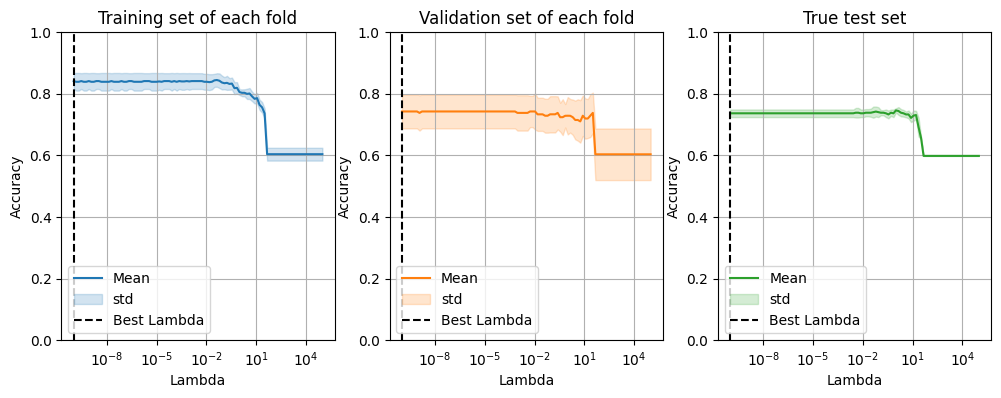

In [616]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

colors = plt.get_cmap('tab10').colors
ax[ 0].plot(lambdas, poisson_deviance_means_train_train, label='Mean', color=colors[0])
ax[1].plot(lambdas, poisson_deviance_means_train_test, label='Mean', color=colors[1])
ax[2].plot(lambdas, poisson_deviance_means_test, label='Mean', color=colors[2])

ax[0].fill_between(lambdas, poisson_deviance_means_train_train - poisson_deviance_stds_train_train, poisson_deviance_means_train_train + poisson_deviance_stds_train_train, alpha=0.2, color=colors[0], label='std')
ax[1].fill_between(lambdas, poisson_deviance_means_train_test - poisson_deviance_stds_train_test, poisson_deviance_means_train_test + poisson_deviance_stds_train_test, alpha=0.2, color=colors[1], label='std')
ax[2].fill_between(lambdas, poisson_deviance_means_test - poisson_deviance_stds_test, poisson_deviance_means_test + poisson_deviance_stds_test, alpha=0.2, color=colors[2], label='std')

# ax[0].scatter(lambdas, poisson_deviance_means_train_train, color=colors[0])
# ax[1].scatter(lambdas, poisson_deviance_means_train_test, color=colors[1])
# ax[2].scatter(lambdas, poisson_deviance_means_test, color=colors[2])

# smooth poisson_deviance_means_train_test
# from scipy.ndimage import gaussian_filter1d
# poisson_deviance_means_train_test = gaussian_filter1d(poisson_deviance_means_train_test, sigma=2)
best_lambda = lambdas[np.argmax(poisson_deviance_means_train_test)]

for i in range(3):

    ax[i].set_xscale('log')
    ax[i].set_xlabel('Lambda')
    ax[i].set_ylabel('Accuracy')
    ax[i].grid(True)
    ax[i].vlines(best_lambda, 0, 1, color='black', linestyle='--', label='Best Lambda')
    ax[i].legend(loc='lower left')

    ax[i].set_ylim(0, 1)

for i in range(1, 3):
    ax[i].set_ylim(ax[0].get_ylim())

ax[0].set_title('Training set of each fold')
ax[1].set_title('Validation set of each fold')
ax[2].set_title('True test set')



plt.savefig(f'{FOLDER_EXPORTS}/logistic_regression_lasso_deviance_vs_lambda_{"no_log_transform" if not use_log_transformed else "log_transform"}.png')
plt.show()

In [617]:
poisson_deviance_means_test, best_lambda, np.argmax(poisson_deviance_means_test), lambdas[np.argmax(poisson_deviance_means_test)]

(array([0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
        0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
        0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
        0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
        0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
        0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
        0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
        0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
        0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
        0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
        0.73831776, 0.73831776, 0.7364486 , 0.7364486 , 0.73831776,
        0.73831776, 0.73831776, 0.74018692, 0.74205607, 0.74018692,
        0.73831776, 0.73831776, 0.7364486 , 0.73271028, 0.73831776,
        0.7364486 , 0.74579439, 0.74392523, 0.73831776, 0.7364486 ,
        0.73271028, 0.73271028, 0.72149533, 0.72

In [618]:
# accuracies...
model = LogisticRegression(
    penalty='l1',
    # l1_ratio=1.0,
    C=1/best_lambda,
    solver='liblinear',
    max_iter=1_000
)
model.fit(X_train, y_train)



y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, y_pred_train))
print('Test accuracy:', accuracy_score(y_test, y_pred_test))


Training accuracy: 0.8294930875576036
Test accuracy: 0.719626168224299


### Coefficient history

In [597]:
# use_log_transformed = True

if use_log_transformed:
    X_train = train_df[features].values
    y_train = train_df["bugbin"].values

    X_test  = test_df[features].values
    y_test  = test_df["bugbin"].values
else:
    # code for running on the normalized but not log transformed data
    X_train = train_df_normalized[features].values
    y_train = train_df["bugbin"].values

    X_test  = test_df_normalized[features].values
    y_test  = test_df["bugbin"].values

# code for running on the normalized but not log transformed data
# X_train = train_df_raw[features].values
# y_train = train_df_raw["bugs"].values

# X_test  = test_df_raw[features].values
# y_test  = test_df_raw["bugs"].values

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test  = scaler.transform(X_test)

# coefficients_beta0_means = []
coefficients_beta_means = []

# coefficients_beta0_stds = []
coefficients_beta_stds = []

# lambdas = np.logspace(-10, -1, 100)
# lambdas = np.linspace(np.log(1e-4), np.log(0), 100)
# print(lambdas)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# best_lambda = None
# best_score = np.inf

poisson_deviance_means_train_train = []
poisson_deviance_means_train_test = []
poisson_deviance_means_test = []

poisson_deviance_stds_train_train = []
poisson_deviance_stds_train_test = []
poisson_deviance_stds_test = []

for lam in tqdm(lambdas, desc="Lambda", total=len(lambdas)):
    fold_scores_train_train = []
    fold_scores_train_test = []
    fold_scores_test = []

    coefficients_beta0 = []
    coefficients_beta = []


    for tr_idx, val_idx in kf.split(X_train):
        with warnings.catch_warnings():
            # warnings.filterwarnings("ignore", category=ConvergenceWarning)
            # warnings.filterwarnings("ignore", category=UserWarning)
            model = LogisticRegression(
                penalty='l1',
                # l1_ratio=1.0,
                C=1/lam,
                solver='liblinear',
                max_iter=1_000
            )
            # model.fit(X_train[tr_idx], y_train[tr_idx])
            model.fit(X_train[tr_idx], y_train[tr_idx])

        y_train_pred = model.predict(X_train[tr_idx])
        y_val_pred = model.predict(X_train[val_idx])
        y_test_pred = model.predict(X_test)

        fold_scores_train_train.append(accuracy_score(y_train[tr_idx], y_train_pred))
        fold_scores_train_test.append(accuracy_score(y_train[val_idx], y_val_pred))
        fold_scores_test.append(accuracy_score(y_test, y_test_pred))

        # print(model.coef_.reshape.shape)
        # print(model.coef_)
        # break
        # assert False

        # coefficients_beta0.append(model.beta0_)
        coefficients_beta.append(model.coef_)

    # coefficients_beta0 = np.array(coefficients_beta0)
    coefficients_beta = np.array(coefficients_beta)

    # coefficients_beta0_means.append(coefficients_beta0.mean(axis=0))
    coefficients_beta_means.append(coefficients_beta.mean(axis=0))

    # coefficients_beta0_stds.append(coefficients_beta0.std(axis=0))
    coefficients_beta_stds.append(coefficients_beta.std(axis=0))

    # compute the means 
    poisson_deviance_means_train_train.append(np.mean(fold_scores_train_train))
    poisson_deviance_means_train_test.append(np.mean(fold_scores_train_test))
    poisson_deviance_means_test.append(np.mean(fold_scores_test))

    # compute the stds
    poisson_deviance_stds_train_train.append(np.std(fold_scores_train_train))
    poisson_deviance_stds_train_test.append(np.std(fold_scores_train_test))
    poisson_deviance_stds_test.append(np.std(fold_scores_test))

poisson_deviance_means_train_train = np.array(poisson_deviance_means_train_train)
poisson_deviance_means_train_test = np.array(poisson_deviance_means_train_test)
poisson_deviance_means_test = np.array(poisson_deviance_means_test)

poisson_deviance_stds_train_train = np.array(poisson_deviance_stds_train_train)
poisson_deviance_stds_train_test = np.array(poisson_deviance_stds_train_test)
poisson_deviance_stds_test = np.array(poisson_deviance_stds_test)

# coefficients_beta0_means = np.array(coefficients_beta0_means)
coefficients_beta_means = np.array(coefficients_beta_means).squeeze()
# coefficients_beta_means = coefficients_beta_means.squeeze()

# coefficients_beta0_stds = np.array(coefficients_beta0_stds)
coefficients_beta_stds = np.array(coefficients_beta_stds).squeeze()

Lambda: 100%|██████████| 100/100 [00:03<00:00, 26.67it/s]


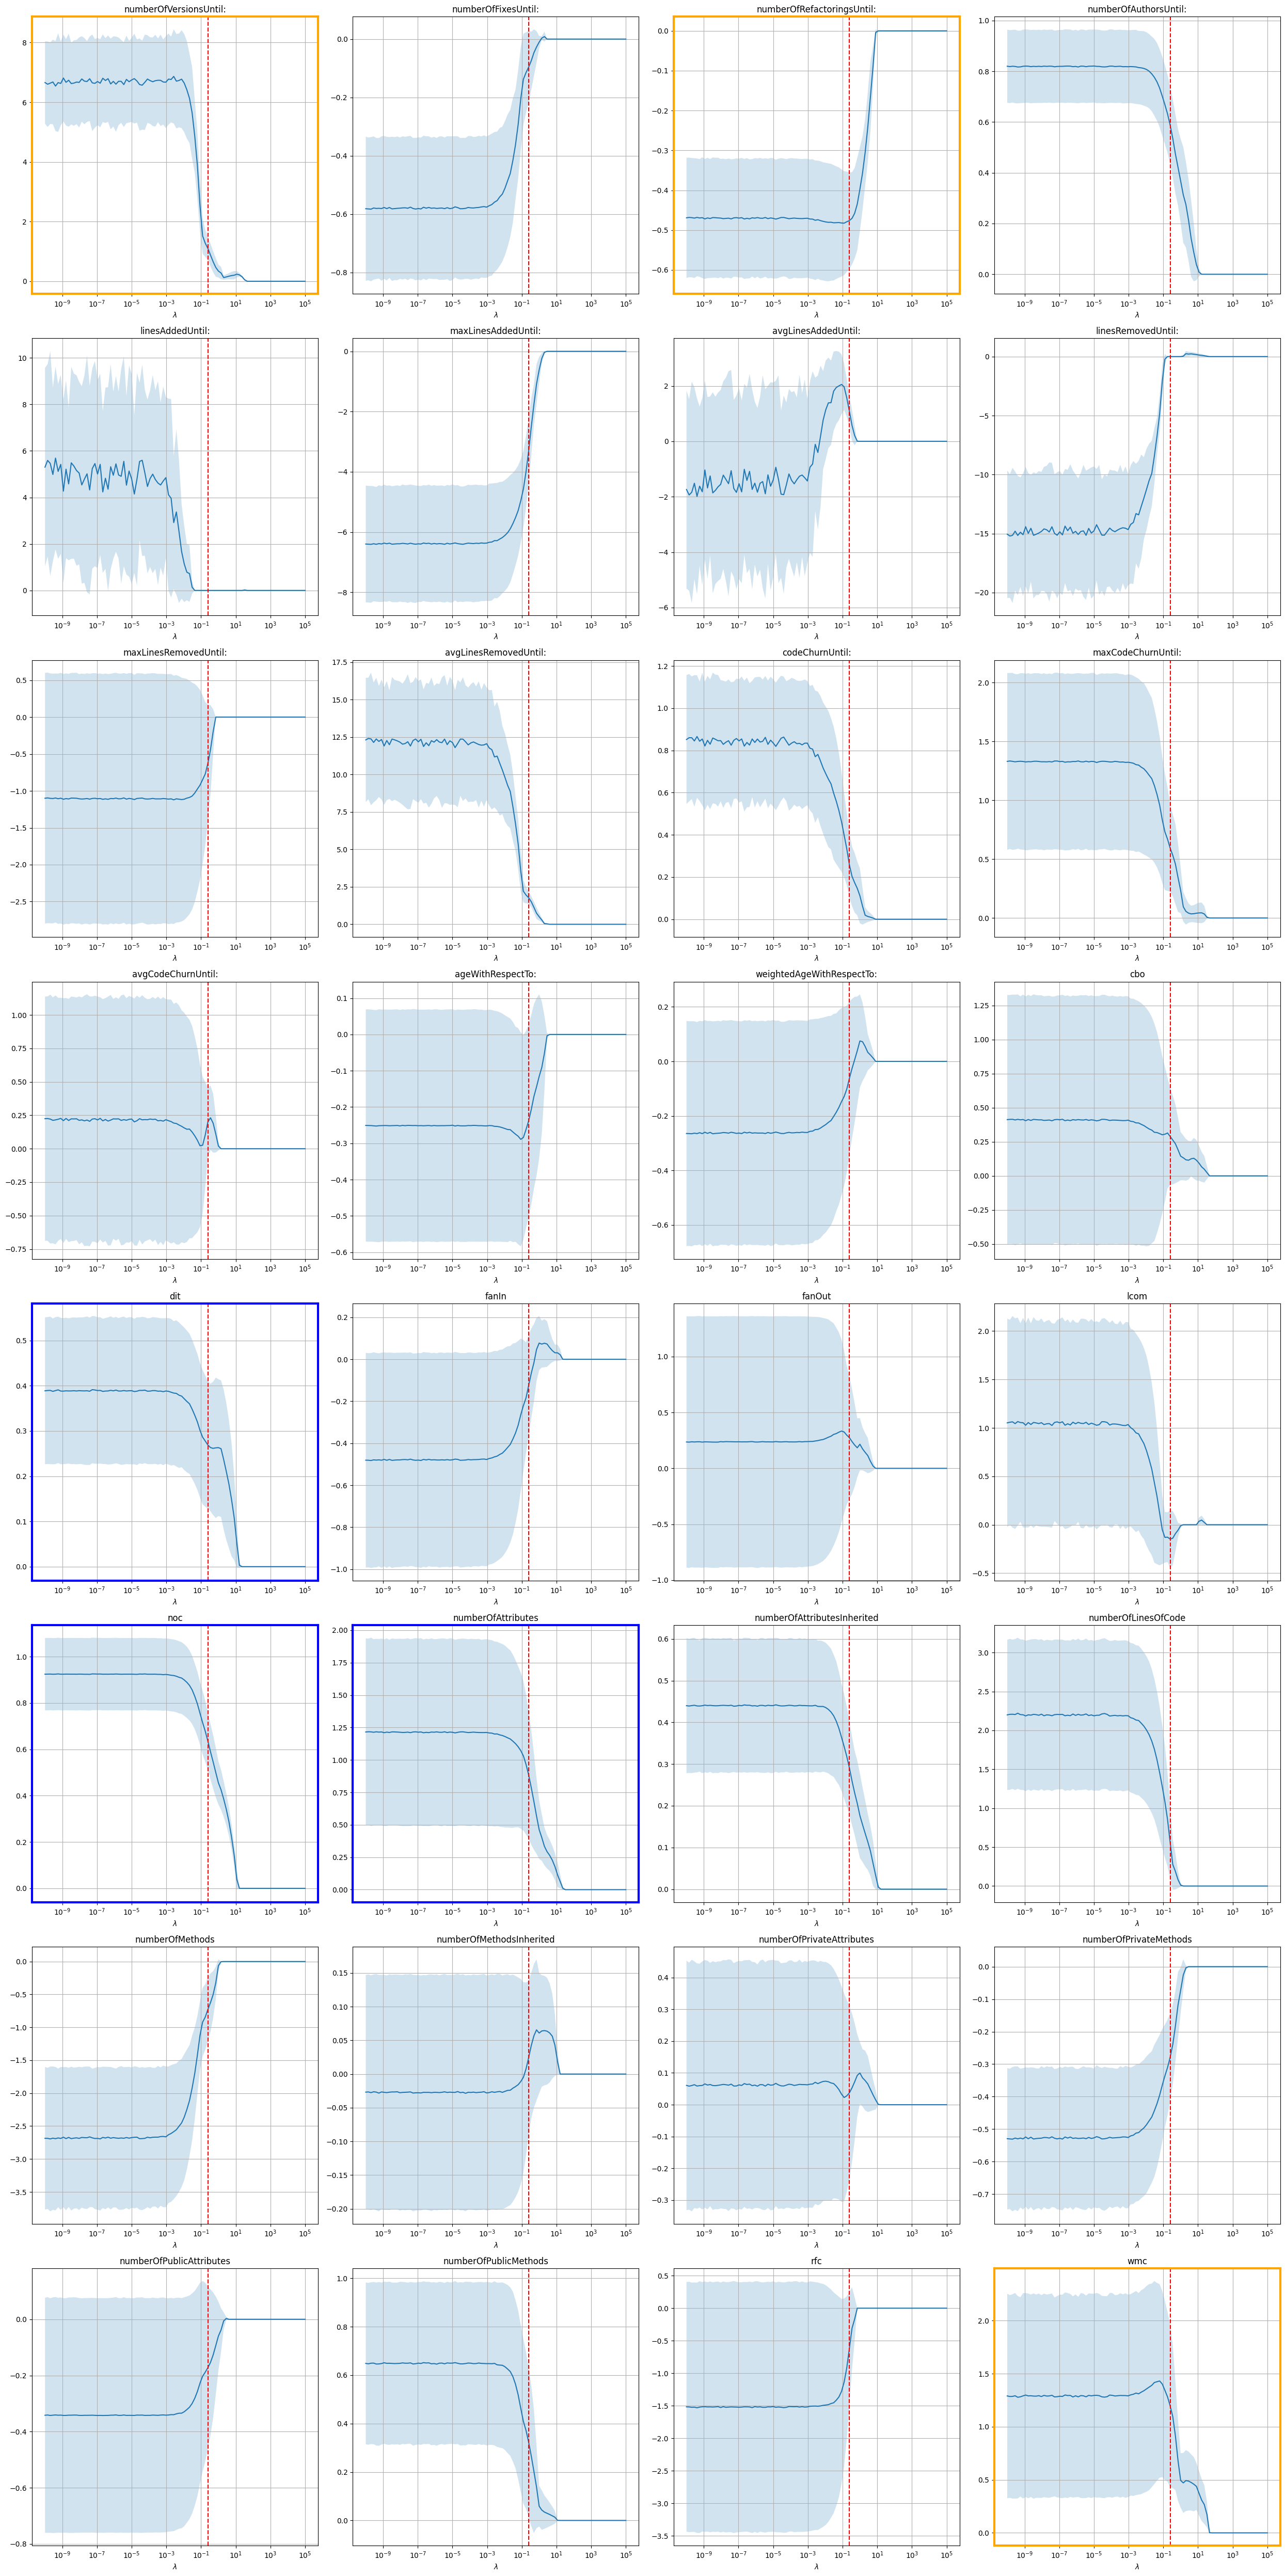

In [586]:
# plot each of the 32 coefficients in a separate plot 
fig, axs = plt.subplots(8, 4, figsize=(25, 50))

# get lambda with the lowest test deviance 
# best_lambda = lambdas[np.argmin()]
# best_lambda_idx = np.argmax(poisson_deviance_means_train_test)
# # lambdas[best_lambda_idx]
# best_lambda = lambdas[best_lambda_idx]
# print(best_lambda)

for i in range(32):
    ax = axs[i // 4, i % 4]
    ax.plot(lambdas, coefficients_beta_means[:, i], label='mean')
    ax.fill_between(lambdas, coefficients_beta_means[:, i] - coefficients_beta_stds[:, i], coefficients_beta_means[:, i] + coefficients_beta_stds[:, i], alpha=0.2)
    ax.set_xscale('log')
    ax.set_xlabel('$\\lambda$')
    # ax.set_ylabel('Coefficient')
    ax.set_title(df.columns[i])
    # ax.legend()
    ax.grid(True)

    ax.axvline(best_lambda, color='red', linestyle='--', label='Best Lambda')

    if df.columns[i] in stepwise_features_bic_logistic:
        for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_color('orange')
    elif df.columns[i] in stepwise_features_aic_logistic:
        for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_color('blue')
fig.tight_layout()
fig.savefig(f'{FOLDER_EXPORTS}/logistic_regression_lasso_coefficients_{"log_transform" if use_log_transformed else "no_log_transform"}.png')

In [619]:
poisson_deviance_means_test

array([0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
       0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
       0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
       0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
       0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
       0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
       0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
       0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
       0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
       0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 , 0.7364486 ,
       0.73831776, 0.73831776, 0.7364486 , 0.7364486 , 0.73831776,
       0.73831776, 0.73831776, 0.74018692, 0.74205607, 0.74018692,
       0.73831776, 0.73831776, 0.7364486 , 0.73271028, 0.73831776,
       0.7364486 , 0.74579439, 0.74392523, 0.73831776, 0.7364486 ,
       0.73271028, 0.73271028, 0.72149533, 0.72897196, 0.73084

In [587]:
# best_lambda_idx = np.argmax(poisson_deviance_means_train_test)
# lambdas[best_lambda_idx]
best_lambda

np.float64(0.2477076355991714)

In [588]:
model = LogisticRegression(
    penalty='l1',
    C=1/best_lambda,
    solver='liblinear',
    max_iter=1_000
)
model.fit(X_train, y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,np.float64(4.03701725859655)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [589]:
model.coef_

array([[ 1.22074787, -0.13882181, -0.43897037,  0.5401435 ,  0.        ,
        -3.7195329 ,  1.65241587,  0.        , -0.25118557,  1.35688628,
         0.27081113,  0.5059265 ,  0.06554354, -0.23563182, -0.10896131,
         0.19394728,  0.29052977, -0.1383025 ,  0.1076832 ,  0.        ,
         0.61133936,  0.89542368,  0.2639338 ,  0.49728158, -0.8979161 ,
         0.        ,  0.03795211, -0.29979744, -0.18428777,  0.31805207,
        -0.14218679,  1.0027437 ]])

In [591]:
def analyze_prediction_increase_parameters_logistic(_model, _selected_features, _all_features, _scaler, _min_add: np.ndarray | None = None) -> np.ndarray:
    std = np.sqrt(_scaler.var_)

    stds_parameters = []
    for feature in _selected_features:
        feature_index = _all_features.index(feature)
        # stds_parameters.append
        stds_parameters.append(std[feature_index])

    ratios = []
    if _min_add is None:
        # normalized data
        for fid, feature in enumerate(_selected_features):
            delta = 1 / stds_parameters[fid]

            ratios.append(np.exp(_model.coef_[0, fid] * delta))
    else:
        # log transformed & Normalized data
        for fid, feature in enumerate(_selected_features):
            delta = np.log(1 + _min_add[fid] + 1) / stds_parameters[fid]

            ratios.append(np.exp(_model.coef_[0, fid] * delta))

    return np.array(ratios)


In [ ]:
print(stepwise_features_bic)
if not use_log_transformed:
    print('Using min_val=None')
    print(analyze_prediction_increase_parameters_logistic(model, features, features, scaler_normalized, _min_add=None))
    ratios = (analyze_prediction_increase_parameters_logistic(model, features, features, scaler_normalized, _min_add=None))
else:
    print('Using min_val')
    ratios = (analyze_prediction_increase_parameters_logistic(model, features, features, scaler_log_transformed, _min_add=min_val))

['cbo', 'linesRemovedUntil:', 'numberOfMethodsInherited']
Using min_val
[4.36739989e+00 8.76163411e-01 3.18797710e-01 4.18771135e+00
 1.00000000e+00 3.13774664e-01 2.14063751e+00 1.00000000e+00
 9.17226565e-01 2.20628908e+00 1.09986341e+03 1.17957968e+00
 1.32410696e+00 4.14510107e-01 9.58923841e-01 1.13420955e+00
 1.09717589e+01 8.93439653e-01 1.07239131e+00 1.00000000e+00
 4.31421747e+00 1.72644920e+00 1.28356236e+00 1.19755633e+00
 5.50441395e-01 1.00000000e+00 1.02774819e+00 7.76159604e-01
 8.34514928e-01 1.28124586e+00 9.41249735e-01 1.56962382e+00]


In [553]:
features

['numberOfVersionsUntil:',
 'numberOfFixesUntil:',
 'numberOfRefactoringsUntil:',
 'numberOfAuthorsUntil:',
 'linesAddedUntil:',
 'maxLinesAddedUntil:',
 'avgLinesAddedUntil:',
 'linesRemovedUntil:',
 'maxLinesRemovedUntil:',
 'avgLinesRemovedUntil:',
 'codeChurnUntil:',
 'maxCodeChurnUntil:',
 'avgCodeChurnUntil:',
 'ageWithRespectTo:',
 'weightedAgeWithRespectTo:',
 'cbo',
 'dit',
 'fanIn',
 'fanOut',
 'lcom',
 'noc',
 'numberOfAttributes',
 'numberOfAttributesInherited',
 'numberOfLinesOfCode',
 'numberOfMethods',
 'numberOfMethodsInherited',
 'numberOfPrivateAttributes',
 'numberOfPrivateMethods',
 'numberOfPublicAttributes',
 'numberOfPublicMethods',
 'rfc',
 'wmc']

In [554]:
ratios = [1.00932623, 0.66980951, 0.257643, 1.26945914, 1.0028218, 1.00825187
, 0.99196602, 1.01029337, 0.97678414, 1.04362714, 0.99723489, 0.9978825
, 0.98811035, 0.99773488, 1.01157954, 1.31868045, 3.21919906, 0.76305693
, 0.89392576, 1.00370288, 3.33496413, 1.07067763, 1.0593115, 1.00749901
, 0.72716729, 1.02381274, 1.03947107, 1.12920818, 0.9156895, 1.27738279
, 0.96628554, 1.05011304]

In [ ]:
best_lambda

np.float64(0.7423890063424947)

In [564]:
merged = list(zip(features, ratios, model.coef_.reshape(-1).tolist()))

sorted(merged, key=lambda x: abs(x[1]), reverse=True)
# merge

[('noc', 3.33496413, 0.7343900826013865),
 ('dit', 3.21919906, 0.5668626503127201),
 ('cbo', 1.31868045, 3.0195028780296633),
 ('numberOfPublicMethods', 1.27738279, 1.6314582075502215),
 ('numberOfAuthorsUntil:', 1.26945914, 0.5066452593677842),
 ('numberOfPrivateMethods', 1.12920818, 0.6543012451988406),
 ('numberOfAttributes', 1.07067763, 0.9315621179899133),
 ('numberOfAttributesInherited', 1.0593115, 0.3347767352460666),
 ('wmc', 1.05011304, 2.7306441439398546),
 ('avgLinesRemovedUntil:', 1.04362714, 0.5666900104118255),
 ('numberOfPrivateAttributes', 1.03947107, 0.1973230693662476),
 ('numberOfMethodsInherited', 1.02381274, 0.33257428420552715),
 ('weightedAgeWithRespectTo:', 1.01157954, 0.3844694537671329),
 ('linesRemovedUntil:', 1.01029337, 3.6760956674022642),
 ('numberOfVersionsUntil:', 1.00932623, 0.17502832871110005),
 ('maxLinesAddedUntil:', 1.00825187, 1.290023542275205),
 ('numberOfLinesOfCode', 1.00749901, 1.505687582150328),
 ('lcom', 1.00370288, 0.9879546722468303),
 

### AUROC scores

In [621]:
from sklearn.metrics import roc_auc_score

In [624]:
use_log_transformed = False

if use_log_transformed:
    X_train = train_df[features].values
    y_train = train_df["bugbin"].values

    X_test  = test_df[features].values
    y_test  = test_df["bugbin"].values
else:
    # code for running on the normalized but not log transformed data
    X_train = train_df_normalized[features].values
    y_train = train_df["bugbin"].values

    X_test  = test_df_normalized[features].values
    y_test  = test_df["bugbin"].values

    # scaler = StandardScaler()
    # X_train = scaler.fit_transform(X_train)
    # X_test  = scaler.transform(X_test)

lambdas = np.logspace(-10, 5, 100)
# lambdas = np.linspace(np.log(1e-4), np.log(0), 100)
# print(lambdas)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_lambda = None
best_score = np.inf

poisson_deviance_means_train_train = []
poisson_deviance_means_train_test = []
poisson_deviance_means_test = []

poisson_deviance_stds_train_train = []
poisson_deviance_stds_train_test = []
poisson_deviance_stds_test = []

for lam in tqdm(lambdas, desc="Lambda", total=len(lambdas)):
    fold_scores_train_train = []
    fold_scores_train_test = []
    fold_scores_test = []


    for tr_idx, val_idx in kf.split(X_train):
        with warnings.catch_warnings():
            # warnings.filterwarnings("ignore", category=ConvergenceWarning)
            # warnings.filterwarnings("ignore", category=UserWarning)
            model = LogisticRegression(
                penalty='l1',
                # l1_ratio=1.0,
                C=1/lam,
                solver='liblinear',
                max_iter=1_000
            )
            # model.fit(X_train[tr_idx], y_train[tr_idx])
            model.fit(X_train[tr_idx], y_train[tr_idx])
            # model = GLM(
            #     distr="poisson",
            #     alpha=1.0,
            #     reg_lambda=lam,
            #     learning_rate=1e-3,
            #     max_iter=10_000 
            # )
            # model.fit(X_train[tr_idx], y_train[tr_idx])

        y_train_pred = model.predict(X_train[tr_idx])
        y_val_pred = model.predict(X_train[val_idx])
        y_test_pred = model.predict(X_test)

        fold_scores_train_train.append(roc_auc_score(y_train[tr_idx], y_train_pred))
        fold_scores_train_test.append(roc_auc_score(y_train[val_idx], y_val_pred))
        fold_scores_test.append(roc_auc_score(y_test, y_test_pred))

    # compute the means 
    poisson_deviance_means_train_train.append(np.mean(fold_scores_train_train))
    poisson_deviance_means_train_test.append(np.mean(fold_scores_train_test))
    poisson_deviance_means_test.append(np.mean(fold_scores_test))

    # compute the stds
    poisson_deviance_stds_train_train.append(np.std(fold_scores_train_train))
    poisson_deviance_stds_train_test.append(np.std(fold_scores_train_test))
    poisson_deviance_stds_test.append(np.std(fold_scores_test))

poisson_deviance_means_train_train = np.array(poisson_deviance_means_train_train)
poisson_deviance_means_train_test = np.array(poisson_deviance_means_train_test)
poisson_deviance_means_test = np.array(poisson_deviance_means_test)

poisson_deviance_stds_train_train = np.array(poisson_deviance_stds_train_train)
poisson_deviance_stds_train_test = np.array(poisson_deviance_stds_train_test)
poisson_deviance_stds_test = np.array(poisson_deviance_stds_test)

Lambda: 100%|██████████| 100/100 [00:04<00:00, 23.67it/s]


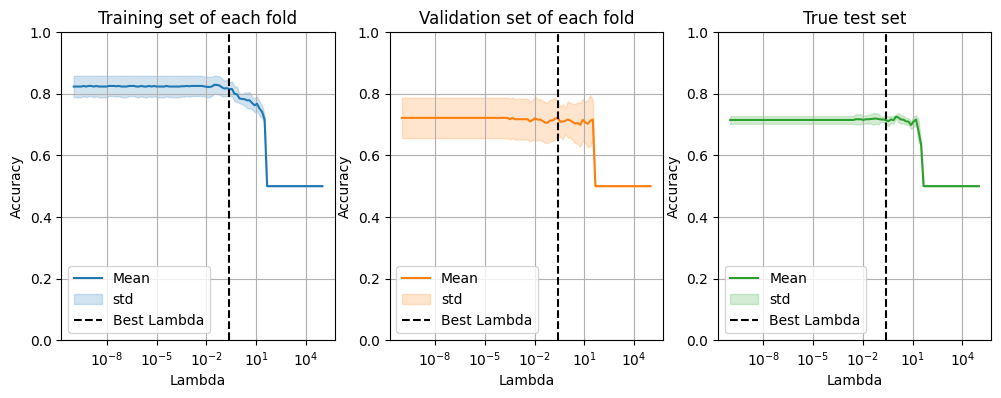

In [625]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

colors = plt.get_cmap('tab10').colors
ax[0].plot(lambdas, poisson_deviance_means_train_train, label='Mean', color=colors[0])
ax[1].plot(lambdas, poisson_deviance_means_train_test, label='Mean', color=colors[1])
ax[2].plot(lambdas, poisson_deviance_means_test, label='Mean', color=colors[2])

ax[0].fill_between(lambdas, poisson_deviance_means_train_train - poisson_deviance_stds_train_train, poisson_deviance_means_train_train + poisson_deviance_stds_train_train, alpha=0.2, color=colors[0], label='std')
ax[1].fill_between(lambdas, poisson_deviance_means_train_test - poisson_deviance_stds_train_test, poisson_deviance_means_train_test + poisson_deviance_stds_train_test, alpha=0.2, color=colors[1], label='std')
ax[2].fill_between(lambdas, poisson_deviance_means_test - poisson_deviance_stds_test, poisson_deviance_means_test + poisson_deviance_stds_test, alpha=0.2, color=colors[2], label='std')

# ax[0].scatter(lambdas, poisson_deviance_means_train_train, color=colors[0])
# ax[1].scatter(lambdas, poisson_deviance_means_train_test, color=colors[1])
# ax[2].scatter(lambdas, poisson_deviance_means_test, color=colors[2])

# smooth poisson_deviance_means_train_test
# from scipy.ndimage import gaussian_filter1d
# poisson_deviance_means_train_test = gaussian_filter1d(poisson_deviance_means_train_test, sigma=2)
best_lambda = lambdas[np.argmax(poisson_deviance_means_train_test)]

for i in range(3):

    ax[i].set_xscale('log')
    ax[i].set_xlabel('Lambda')
    ax[i].set_ylabel('Accuracy')
    ax[i].grid(True)
    ax[i].vlines(best_lambda, 0, 1, color='black', linestyle='--', label='Best Lambda')
    ax[i].legend(loc='lower left')

    ax[i].set_ylim(0, 1)

for i in range(1, 3):
    ax[i].set_ylim(ax[0].get_ylim())

ax[0].set_title('Training set of each fold')
ax[1].set_title('Validation set of each fold')
ax[2].set_title('True test set')



# plt.savefig(f'{FOLDER_EXPORTS}/logistic_regression_lasso_deviance_vs_lambda_{"no_log_transform" if not use_log_transformed else "log_transform"}.png')
plt.show()